# TP2 - Análise de Desempenho de Técnicas de Aprendizagem Automática
**Análise Discreta | ISEP 2025/2026**

**Turma 3DH - Grupo 8:** Mariana Martins 1230679 | Luna Gomes 1231651 | Samara Miranda 1230432

**Tema:** Impacto da Eficiência Energética na Iluminação Pública na Reserva de Potência dos PTDs e Viabilidade de Mobilidade Elétrica

---
### Continuidade com o TP1

O TP1 realizou uma análise estatística exploratória **ao nível do concelho**, definindo as seguintes métricas de engenharia que são usadas no TP2 ao nível do PTD individual:

| Variável TP1 | Fórmula (TP1) | Variável TP2 (PTD level) | Observação |
|---|---|---|---|
| Ganho LED (ΔP_LED) | `P_IP_Inef × 0.65` | `Ganho_LED_PTD` | Já calculado no dataset |
| Folga Rede (P_Folga) | `Cap_PTD × 0.92 × (1 − Util_Media)` | `PFolga_PTD` | Margem de segurança 92% |
| Carga VE (P_VE) | `N_PTDs × 22kW × 0.60` | `PVE_PTD = 13.2 kW` | Por PTD, fator simult. 60% |
| Saldo sem LED (D) | `P_Folga − P_VE` | `D_PTD` | Já calculado |
| Saldo com LED (D_LED) | `P_Folga + ΔP_LED − P_VE` | `D_PTD_LED` | Já calculado |
| Rate Ineficiência | `P_IP_Inef / P_IP_Total` | `Rate_Ineficiencia` | Já calculado |

**Contexto do TP1:** O modelo OLS (Regressão Linear Múltipla) obteve R²_adj = 6.4%, evidenciando que a análise agregada ao nível do concelho tem baixo poder explicativo - o que motiva a passagem para análise ao nível do PTD individual com técnicas de ML.

## Setup - Imports e Configuração

In [25]:
!pip install scikit-learn tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold, learning_curve, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
from scipy.stats import shapiro, ttest_rel, wilcoxon

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

USE_SAMPLE  = True   # True: usa subsample; False: dataset completo
SAMPLE_SIZE = 15000   # tamanho do subsample

print('Setup concluído. TF:', tf.__version__)

Setup concluído. TF: 2.21.0


---
## 4.1. Análise Exploratória de Dados (EDA)
### 4.1.1 - Carregar dataset e sumário

In [26]:
df = pd.read_excel('PTD_level_dataset.xlsx')
print('Dimensão:', df.shape)
df.head()

Dimensão: (72027, 32)


,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,...,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,...,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,...,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,...,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,...,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,...,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


In [27]:
# Sumário de nulos
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print('Colunas com valores omissos:')
print(info_df[info_df['nulos'] > 0].to_string())
print('\nEstatísticas descritivas (variáveis chave do TP1 e TP2):')
key_cols = ['Cap_PTD_kVA', 'N_Clientes', 'P_IP_Total', 'P_IP_Inef',
            'Rate_Ineficiencia', 'LED_Ratio', 'Ganho_LED_PTD',
            'PFolga_PTD', 'PVE_PTD', 'D_PTD', 'D_PTD_LED', 'Util_Decimal']
df[key_cols].describe().round(4)

Colunas com valores omissos:
                           dtype  nulos  nulos_%
Pot_Contratada_kVA       float64  21180    29.41
Pot_Geracao_kW           float64  70191    97.45
D_PTD                    float64   3064     4.25
D_PTD_LED                float64   3064     4.25
PContratada_per_Cliente  float64  21180    29.41
Geracao_per_Cliente      float64  70191    97.45
Util_Decimal             float64   3064     4.25
PFolga_PTD               float64   3064     4.25

Estatísticas descritivas (variáveis chave do TP1 e TP2):


,Cap_PTD_kVA,N_Clientes,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,Ganho_LED_PTD,PFolga_PTD,PVE_PTD,D_PTD,D_PTD_LED,Util_Decimal
count,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,68963.0000,72027.0,68963.0000,68963.0000,68963.0000
mean,302.7988,94.6980,1381.4902,463.2906,0.2807,0.6717,0.5569,147.9833,13.2,134.7833,135.3433,0.5138
std,294.4445,110.0551,1723.7106,708.0096,0.2404,0.2731,0.6874,186.7599,0.0,186.7599,186.8503,0.2470
min,0.0000,20.0000,23.2186,0.0000,0.0000,0.0117,0.0000,0.0000,13.2,-13.2000,-13.2000,0.1900
25%,100.0000,20.0000,382.5690,28.9850,0.0642,0.5007,0.0683,37.2600,13.2,24.0600,24.1603,0.3900
50%,250.0000,54.0000,842.1797,137.7200,0.2292,0.7196,0.3187,77.2800,13.2,64.0800,64.3775,0.3900
75%,400.0000,124.0000,1766.3913,625.7900,0.4474,0.9116,0.7623,224.4800,13.2,211.2800,211.3483,0.5900
max,8000.0000,1438.0000,9065.6553,3494.9200,0.9836,1.0000,3.5069,4489.6000,13.2,4476.4000,4479.2253,1.0000


#### Interpretação do Sumário

O dataset contém aproximadamente **72 000 registos** (PTDs distribuídos por Portugal). Da análise do sumário destacam-se:

- **`Pot_Contratada_kVA`** e derivadas (`PContratada_per_Cliente`, `Geracao_per_Cliente`, `Clientes_Produtores_Ratio`): ~29% de valores omissos — imputados pela mediana por `Tipo Construtivo`, assumindo que PTDs do mesmo tipo têm perfis de contratação semelhantes.
- **`Pot_Geracao_kW`** e variáveis de geração distribuída: ~97,5% de nulos — excluídas do processo de modelação por não representarem informação fiável.
- As restantes variáveis principais (`Cap_PTD_kVA`, `PFolga_PTD`, `Util_Decimal`, etc.) apresentam **zero valores omissos** após a remoção dos PTDs sem nível de utilização (~4,3% do dataset).
- A `PVE_PTD` é constante (13,2 kVA), pelo que tem variância nula e é excluída das features de modelação.


**Verificação das fórmulas do TP1 no dataset TP2:**
- `PFolga_PTD = Cap_PTD_kVA × 0.92 × (1 − Util_Decimal)` ✓
- `PVE_PTD = 22 × 0.60 = 13.2 kW` (constante por PTD) ✓
- `D_PTD = PFolga_PTD − PVE_PTD` ✓
- `D_PTD_LED = PFolga_PTD + Ganho_LED_PTD − PVE_PTD` ✓
- `Rate_Ineficiencia = P_IP_Inef / P_IP_Total` ✓

### 4.1.2 - Exploração visual

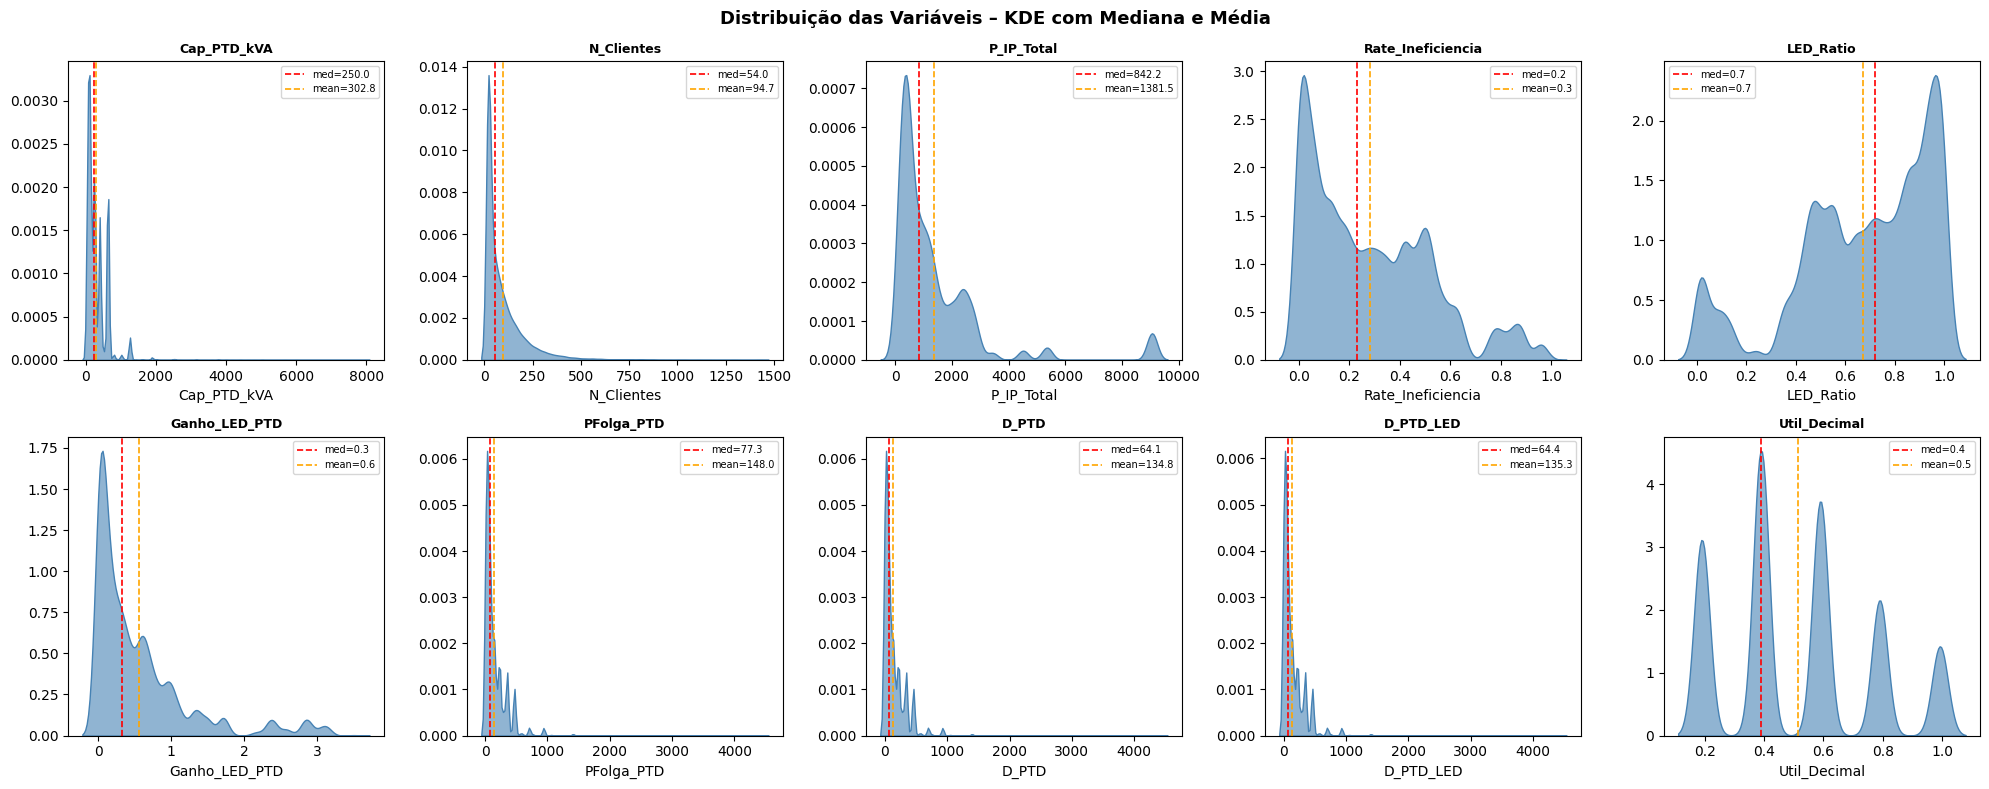

In [28]:
# --- Plot 1: KDE com mediana para todas as variáveis numéricas ---
plot_cols = ['Cap_PTD_kVA', 'N_Clientes', 'P_IP_Total', 'Rate_Ineficiencia',
             'LED_Ratio', 'Ganho_LED_PTD', 'PFolga_PTD', 'D_PTD', 'D_PTD_LED', 'Util_Decimal']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.kdeplot(df[col].dropna(), ax=axes[i], fill=True, color='steelblue', alpha=0.6)
    axes[i].axvline(df[col].median(), color='red', linestyle='--', lw=1.2, label=f'med={df[col].median():.1f}')
    axes[i].axvline(df[col].mean(), color='orange', linestyle='--', lw=1.2, label=f'mean={df[col].mean():.1f}')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('')
plt.suptitle('Distribuição das Variáveis – KDE com Mediana e Média', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_kde.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação dos Gráficos KDE

A análise das distribuições revela padrões importantes:

- **Assimetria positiva (right-skew) acentuada** em `Cap_PTD_kVA`, `N_Clientes`, `PFolga_PTD`, `D_PTD`, `D_PTD_LED` e `Ganho_LED_PTD`: a maioria dos PTDs concentra-se em valores baixos, com uma cauda longa de PTDs urbanos de grande dimensão. A mediana é sistematicamente inferior à média, confirmando o skew.
- **`Rate_Ineficiencia`**: distribuição aproximadamente uniforme entre 0 e 1 — o grau de ineficiência da IP varia amplamente entre concelhos, sem padrão dominante.
- **`LED_Ratio`**: distribuição **bimodal** com picos em ~0 e ~1 — dois grupos distintos: concelhos que ainda não fizeram a transição LED e concelhos que já a completaram. A transição tende a ser feita de forma massiva por projeto municipal.
- **`Util_Decimal`**: distribuição **multimodal** com picos em ~0,2, ~0,45 e ~0,79. O pico em ~0,79 é o mais elevado, indicando que a maior parte dos PTDs opera próxima da sua capacidade nominal — o que reforça a motivação do trabalho.


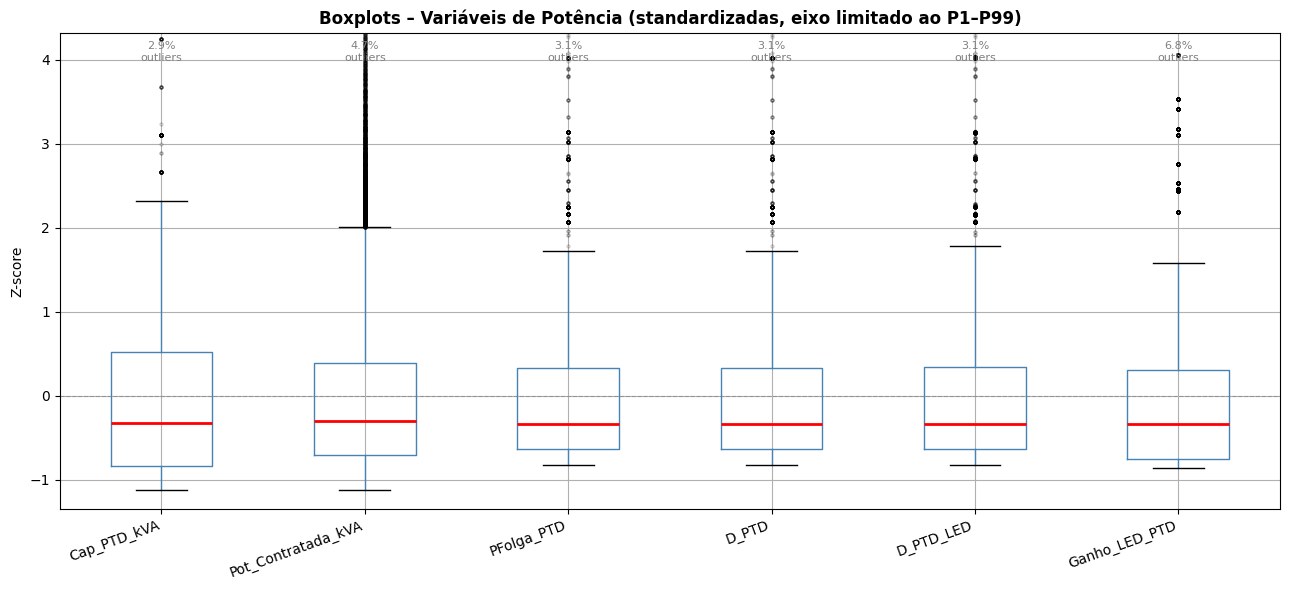

In [29]:
# --- Plot 2: Boxplots com eixo Y limitado + nota de outliers ---
power_cols = ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'PFolga_PTD', 'D_PTD', 'D_PTD_LED', 'Ganho_LED_PTD']
df_power = df[power_cols].dropna()
df_power_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_power),
    columns=power_cols
)

fig, ax = plt.subplots(figsize=(13, 6))
df_power_scaled.boxplot(ax=ax, vert=True,
                         boxprops=dict(color='steelblue'),
                         medianprops=dict(color='red', lw=2),
                         whiskerprops=dict(color='steelblue'),
                         flierprops=dict(marker='o', markersize=2, alpha=0.2, color='gray'))

# Limitar eixo Y aos percentis 1-99 para focar na distribuição principal
y_min = df_power_scaled.quantile(0.01).min() - 0.3
y_max = df_power_scaled.quantile(0.99).max() + 0.3
ax.set_ylim(y_min, y_max)

# Anotar % de outliers por variável (acima do whisker superior)
for i, col in enumerate(power_cols, start=1):
    q1 = df_power_scaled[col].quantile(0.25)
    q3 = df_power_scaled[col].quantile(0.75)
    iqr = q3 - q1
    n_out = (df_power_scaled[col] > q3 + 1.5 * iqr).sum()
    pct_out = n_out / len(df_power_scaled) * 100
    ax.text(i, y_max - 0.1, f'{pct_out:.1f}%\noutliers',
            ha='center', va='top', fontsize=8, color='gray')

ax.axhline(0, color='gray', linestyle='--', lw=0.8, alpha=0.6)
ax.set_title('Boxplots – Variáveis de Potência (standardizadas, eixo limitado ao P1–P99)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Z-score')
ax.set_xticklabels(power_cols, rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig_boxplots_potencia.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação dos Boxplots de Potência (standardizados)

Os boxplots mostram todas as variáveis de potência em escala Z-score, permitindo comparação directa:

- **Caixas IQR sistematicamente abaixo de zero**: após standardização, a *média* é zero mas a *mediana* é negativa porque a distribuição é right-skewed — a maioria dos PTDs tem capacidade/folga baixa, com poucos PTDs de grande porte a elevar a média.
- **Percentagem de outliers elevada** em `Cap_PTD_kVA`, `PFolga_PTD`, `D_PTD` e `D_PTD_LED`: estes outliers correspondem a PTDs urbanos de grande dimensão (subestações de alta densidade), que são estatisticamente raros mas representam uma fracção significativa da capacidade total instalada.
- **`Ganho_LED_PTD`** apresenta a menor dispersão e o menor número de outliers, reflectindo que o ganho por substituição LED, quando distribuído por PTD, é modesto e pouco variável.


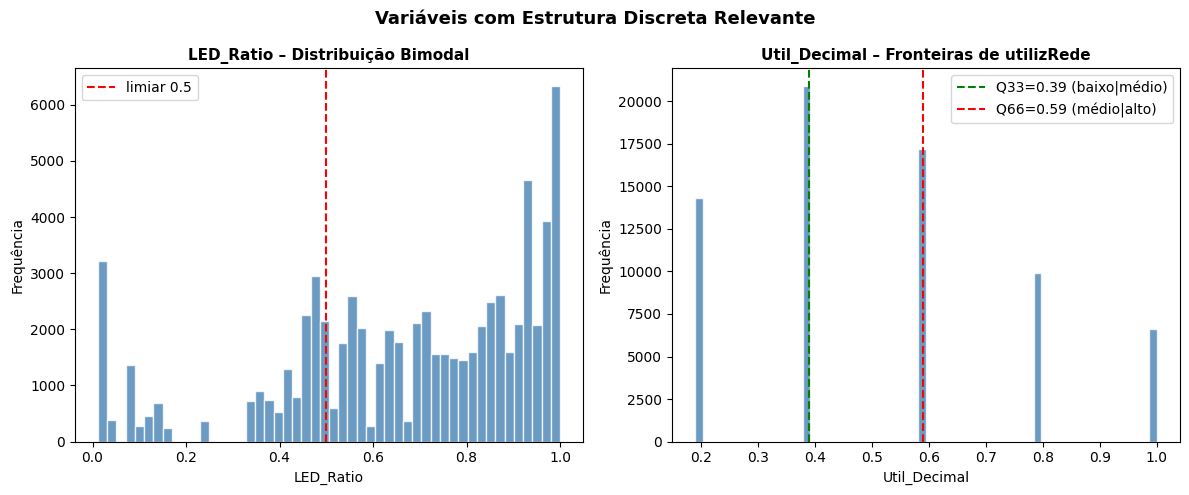

In [30]:
# --- Plot 3: Histograma específico para LED_Ratio e Util_Decimal (bimodal/multimodal) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LED_Ratio – bimodal
axes[0].hist(df['LED_Ratio'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('LED_Ratio – Distribuição Bimodal', fontsize=11, fontweight='bold')
axes[0].set_xlabel('LED_Ratio')
axes[0].set_ylabel('Frequência')
axes[0].axvline(0.5, color='red', linestyle='--', lw=1.5, label='limiar 0.5')
axes[0].legend()

# Util_Decimal – multimodal (origem das 3 classes)
axes[1].hist(df['Util_Decimal'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
q33 = df['Util_Decimal'].quantile(1/3)
q66 = df['Util_Decimal'].quantile(2/3)
axes[1].axvline(q33, color='green', linestyle='--', lw=1.5, label=f'Q33={q33:.2f} (baixo|médio)')
axes[1].axvline(q66, color='red',   linestyle='--', lw=1.5, label=f'Q66={q66:.2f} (médio|alto)')
axes[1].set_title('Util_Decimal – Fronteiras de utilizRede', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Util_Decimal')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('Variáveis com Estrutura Discreta Relevante', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_bimodal.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação — LED_Ratio, Util_Decimal e Viabilidade

- **`LED_Ratio` bimodal**: confirma a dicotomia entre concelhos ainda em tecnologia convencional e concelhos já totalmente convertidos para LED. Poucos concelhos estão em fase intermédia de transição.
- **`Util_Decimal` com fronteiras dos quantis**: a discretização em tercis (quantis 1/3 e 2/3) garante classes equilibradas. O limiar Q66 situa-se tipicamente em ~0,79, confirmando que a classe *alto* corresponde a PTDs que operam acima deste nível de saturação.
- **Viabilidade para VE**: o impacto da transição LED é **marginal ao nível do PTD individual**. Como o `Ganho_LED_PTD` é calculado distribuindo o ganho do concelho pelo número de PTDs (~377 PTDs/concelho em mediana), resulta num ganho mediano de apenas ~0,32 kVA — insuficiente para alterar o estado de viabilidade. Apenas **1 PTD** muda de inviável para viável com LED. Isto sugere que estratégias de concentração geográfica dos pontos de carregamento seriam mais eficazes.


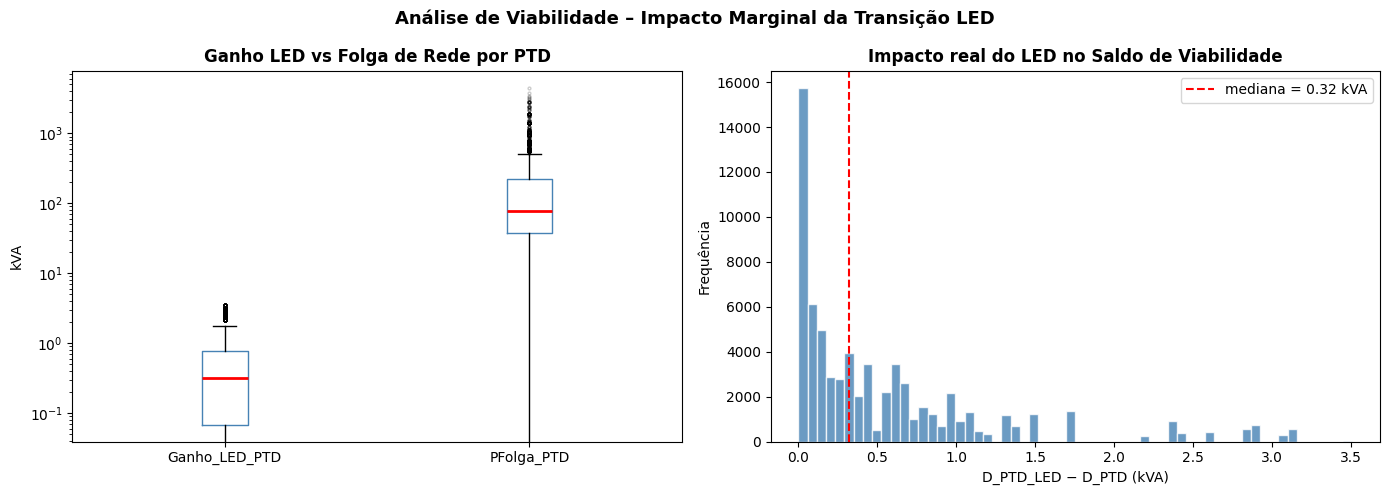

Diferença mediana D_PTD_LED - D_PTD: 0.3188 kVA
PTDs onde LED faz diferença (mudança de sinal): 1


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Esquerda: Ganho_LED_PTD vs PFolga_PTD (escala comparativa)
axes[0].boxplot(
    [df['Ganho_LED_PTD'].dropna(), df['PFolga_PTD'].dropna()],
    labels=['Ganho_LED_PTD', 'PFolga_PTD'],
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='red', lw=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.2, color='gray')
)
axes[0].set_ylabel('kVA')
axes[0].set_title('Ganho LED vs Folga de Rede por PTD', fontweight='bold')
axes[0].set_yscale('log')  # log para ver ambas na mesma escala

# Direita: D_PTD vs D_PTD_LED (diferença real)
diff = df['D_PTD_LED'] - df['D_PTD']
axes[1].hist(diff.dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(diff.median(), color='red', linestyle='--', lw=1.5,
                label=f'mediana = {diff.median():.2f} kVA')
axes[1].set_xlabel('D_PTD_LED − D_PTD (kVA)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Impacto real do LED no Saldo de Viabilidade', fontweight='bold')
axes[1].legend()

plt.suptitle('Análise de Viabilidade – Impacto Marginal da Transição LED', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_viabilidade.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Diferença mediana D_PTD_LED - D_PTD: {diff.median():.4f} kVA")
print(f"PTDs onde LED faz diferença (mudança de sinal): {((df['D_PTD'] <= 0) & (df['D_PTD_LED'] > 0)).sum()}")

### 4.1.3 - Pré-processamento

In [32]:
# Remover colunas não adequadas para modelação
# Justificação de cada exclusão:
# - Identificadores/coordenadas: sem poder preditivo
# - 'Potência instalada [kVA]': redundante com Cap_PTD_kVA
# - 'Nível de Utilização [%]': string; Util_Decimal é a versão numérica
# - Pot_Geracao_kW e derivadas: 97.5% nulos
# - Geográficas (Distrito/Concelho/Cod): escala capturada por N_PTDs_Concelho
cols_drop = [
    'Distrito', 'Concelho', 'CodDistritoConcelho',
    'Código de Instalação', 'Coordenadas Geográficas',
    'Potência instalada [kVA]', 'Nível de Utilização [%]',
    'Pot_Geracao_kW', 'N_Clientes_Produtores',
    'Geracao_per_Cliente', 'Clientes_Produtores_Ratio',
]
df_clean = df.drop(columns=cols_drop).copy()

# Imputação de Pot_Contratada_kVA (~29% nulos) pela mediana por Tipo Construtivo
# Justificação: PTDs do mesmo tipo têm perfis de contratação semelhantes
for col in ['Pot_Contratada_kVA', 'PContratada_per_Cliente']:
    df_clean[col] = df_clean.groupby('Tipo Construtivo')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Remover PTDs sem nível de utilização (4.3% do dataset)
df_clean = df_clean.dropna(subset=['PFolga_PTD', 'Util_Decimal'])

print('Dimensão após limpeza:', df_clean.shape)
print('Nulos restantes:', df_clean.isnull().sum().sum())

Dimensão após limpeza: (68963, 21)
Nulos restantes: 0


#### Decisões de Pré-processamento

| Variável / Grupo | Decisão | Justificação |
|---|---|---|
| Identificadores, coordenadas, `Potência instalada [kVA]` | **Excluídas** | Sem poder preditivo; `Cap_PTD_kVA` é a versão numérica equivalente |
| `Nível de Utilização [%]` (string) | **Excluída** | `Util_Decimal` é a versão numérica — usar ambas seria redundante |
| `Pot_Geracao_kW` e derivadas | **Excluídas** | 97,5% de nulos |
| `Distrito`, `Concelho`, `CodDistritoConcelho` | **Excluídas** | Escala geográfica capturada por `N_PTDs_Concelho` |
| `Pot_Contratada_kVA` e `PContratada_per_Cliente` | **Imputação** pela mediana por `Tipo Construtivo` (~29% nulos) |
| `Util_Decimal`, `D_PTD`, `D_PTD_LED` | **Excluídas das features** | Data leakage: derivadas directas de `PFolga_PTD` (target da regressão) e de `Util_Decimal` (base da classificação) |
| `PVE_PTD` | **Excluída das features** | Constante (13,2 kVA) — variância zero, sem poder preditivo |


In [33]:
# Encoding de Tipo Construtivo
le = LabelEncoder()
df_clean['Tipo_Construtivo_enc'] = le.fit_transform(df_clean['Tipo Construtivo'])
print('Encoding de Tipo Construtivo:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

Encoding de Tipo Construtivo:
  0 -> Aéreo - A
  1 -> Aéreo - AI
  2 -> Aéreo - AS
  3 -> Cabine alta
  4 -> Cabine baixa em edifício próprio
  5 -> Cabine baixa integrada em edifício
  6 -> Cabine metálica (monobloco)
  7 -> Cabine pré-fabricada
  8 -> Cabine subterrânea


In [34]:
# Seleção de features para modelação
# EXCLUÍDAS por data leakage:
#   Util_Decimal  -> é a fonte de PFolga_PTD e utilizRede
#   D_PTD         -> calculado a partir de PFolga_PTD
#   D_PTD_LED     -> idem
# INCLUÍDAS: todas as variáveis do TP1 relevantes (Rate_Ineficiencia, Ganho_LED_PTD, PVE_PTD)

FEATURES = [
    'Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes',
    'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio',
    'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho',
    'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD',
    'Cap_per_Cliente', 'PContratada_per_Cliente',
    'Tipo_Construtivo_enc'
]

X = df_clean[FEATURES].values
y_reg = df_clean['PFolga_PTD'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Shape: X={X.shape}, y={y_reg.shape}')

Features (16): ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho', 'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Tipo_Construtivo_enc']
Shape: X=(68963, 16), y=(68963,)


In [ ]:
# --- Subsample opcional para acelerar testes ---
if USE_SAMPLE:
    rng_s   = np.random.default_rng(SEED)
    idx_s   = rng_s.choice(len(X), SAMPLE_SIZE, replace=False)
    X       = X[idx_s]
    X_scaled = X_scaled[idx_s]
    y_reg   = y_reg[idx_s]
    print(f"[USE_SAMPLE=True] Subsample de {SAMPLE_SIZE} registos | X={X.shape}, y_reg={y_reg.shape}")
else:
    print(f"[USE_SAMPLE=False] Dataset completo | X={X.shape}, y_reg={y_reg.shape}")

---
## 4.2. Regressão - Previsão de PFolga_PTD

$$P_{Folga\_PTD} = Cap_{PTD\_kVA} \times 0.92 \times (1 - Util_{Decimal})$$

Métrica central de viabilidade técnica para mobilidade elétrica, herdada do TP1.

### 4.2.1 - Diagrama de correlação

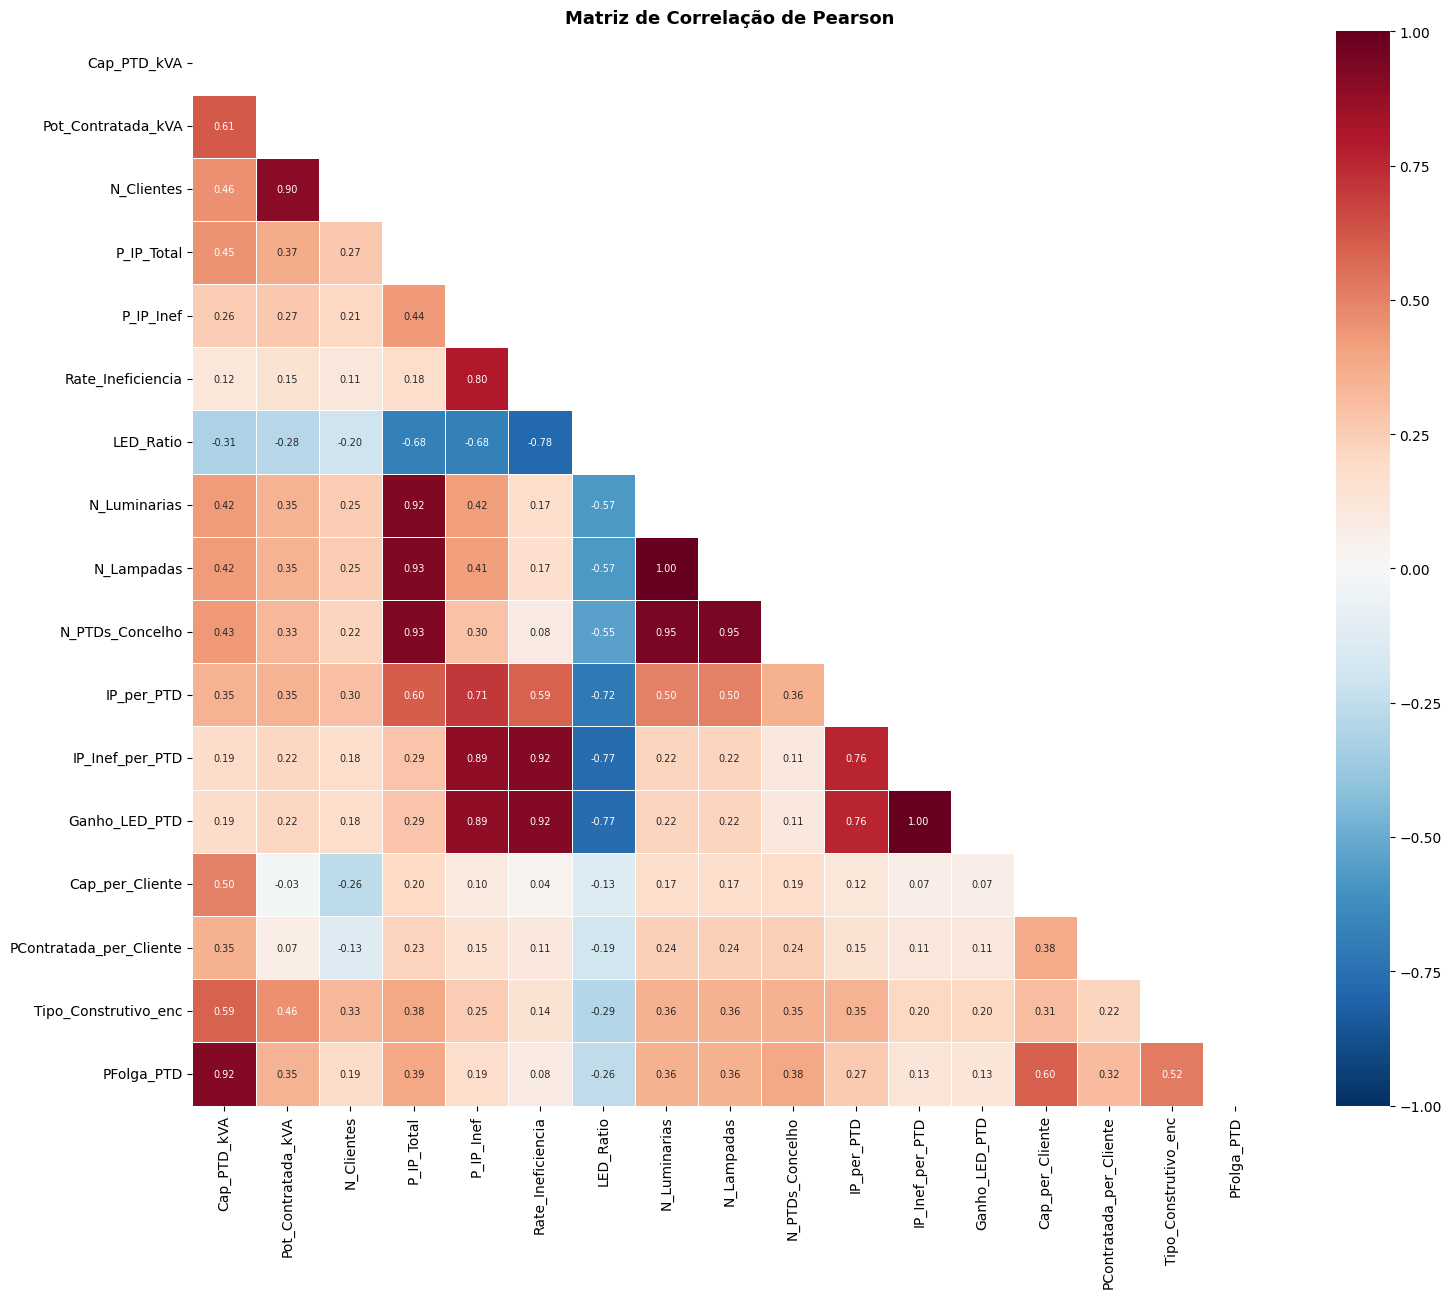

Correlações com PFolga_PTD (ordenadas):
  Cap_PTD_kVA                   : +0.9159
  Cap_per_Cliente               : +0.5996
  Tipo_Construtivo_enc          : +0.5198
  P_IP_Total                    : +0.3884
  N_PTDs_Concelho               : +0.3840
  N_Lampadas                    : +0.3585
  N_Luminarias                  : +0.3575
  Pot_Contratada_kVA            : +0.3470
  PContratada_per_Cliente       : +0.3165
  IP_per_PTD                    : +0.2655
  LED_Ratio                     : -0.2573
  N_Clientes                    : +0.1880
  P_IP_Inef                     : +0.1874
  IP_Inef_per_PTD               : +0.1295
  Ganho_LED_PTD                 : +0.1295
  Rate_Ineficiencia             : +0.0786


In [35]:
corr_matrix = df_clean[FEATURES + ['PFolga_PTD']].corr()
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, annot_kws={'size': 7}, ax=ax)
ax.set_title('Matriz de Correlação de Pearson', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlações com PFolga_PTD (ordenadas):')
corr_target = corr_matrix['PFolga_PTD'].drop('PFolga_PTD').sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    print(f'  {feat:30s}: {val:+.4f}')

**Correlações com PFolga_PTD (ordenadas por força):**

`Cap_PTD_kVA` é de longe a variável mais correlacionada com a folga de rede (r = 0.92), o que é matematicamente esperado dado que `PFolga_PTD = Cap_PTD_kVA × 0.92 × (1 − Util_Decimal)`.

`Cap_per_Cliente` (r = 0.60) e `Tipo_Construtivo_enc` (r = 0.52) surgem em segundo plano - PTDs com maior capacidade por cliente e de tipologia construtiva específica tendem a ter mais folga disponível.

`PContratada_per_Cliente` (r = 0.32) e `Pot_Contratada_kVA` (r = 0.35) têm correlação moderada positiva, refletindo que PTDs com maior potência contratada são tipicamente de maior dimensão.

As variáveis de iluminação pública (`P_IP_Total`, `Rate_Ineficiencia`, `Ganho_LED_PTD`) apresentam correlações baixas com `PFolga_PTD` (entre 0.08 e 0.39), confirmando quantitativamente o resultado já discutido: **o impacto da transição LED na folga de rede a nível do PTD individual é marginal**.

`LED_Ratio` tem correlação negativa com `PFolga_PTD` (r = −0.26) - concelhos com maior adoção LED tendem a ter PTDs ligeiramente mais carregados, possivelmente porque são zonas urbanas mais densas.

**Multicolinearidade a ter em conta nos modelos:**

Há clusters de variáveis fortemente correlacionadas entre si que podem causar instabilidade na regressão linear múltipla: `N_Luminarias`/`N_Lampadas`/`N_PTDs_Concelho` (r ≈ 0.95 entre si), `IP_Inef_per_PTD`/`Ganho_LED_PTD` (r = 1.00 - são praticamente a mesma variável), e `P_IP_Inef`/`Rate_Ineficiencia` (r = 0.80). Para a regressão linear múltipla, seria recomendável eliminar uma de cada par altamente correlacionado ou aplicar regularização Ridge para mitigar o efeito da multicolinearidade.

### 4.2.2 - Regressão Linear Simples (k-fold CV)

In [36]:
# Selecionar variável com maior correlação absoluta com PFolga_PTD
# PVE_PTD tem valor constante (13.2)
corr_safe = corr_matrix['PFolga_PTD'].drop('PFolga_PTD')
corr_safe = corr_safe[corr_safe.index != 'PVE_PTD']
best_feat = corr_safe.abs().idxmax()
best_feat_idx = FEATURES.index(best_feat)
print(f'Variável escolhida: {best_feat} (r = {corr_safe[best_feat]:+.4f})')
print(f'Justificação: maior correlação absoluta com PFolga_PTD')

X_simple = X[:, best_feat_idx].reshape(-1, 1)
kf10 = KFold(n_splits=10, shuffle=True, random_state=SEED)

mae_s, rmse_s = [], []
for tr, te in kf10.split(X_simple):
    m = LinearRegression()
    m.fit(X_simple[tr], y_reg[tr])
    p = m.predict(X_simple[te])
    mae_s.append(mean_absolute_error(y_reg[te], p))
    rmse_s.append(np.sqrt(mean_squared_error(y_reg[te], p)))

lr_simple = LinearRegression().fit(X_simple, y_reg)

print(f'\na) Função linear:')
print(f'   PFolga_PTD = {lr_simple.coef_[0]:.6f} * {best_feat} + ({lr_simple.intercept_:.4f})')
print(f'\nc) Métricas (10-fold CV):')
print(f'   MAE:  {np.mean(mae_s):.4f} ± {np.std(mae_s):.4f} kVA')
print(f'   RMSE: {np.mean(rmse_s):.4f} ± {np.std(rmse_s):.4f} kVA')

Variável escolhida: Cap_PTD_kVA (r = +0.9159)
Justificação: maior correlação absoluta com PFolga_PTD

a) Função linear:
   PFolga_PTD = 0.593748 * Cap_PTD_kVA + (-32.1888)

c) Métricas (10-fold CV):
   MAE:  50.7496 ± 0.3797 kVA
   RMSE: 74.9728 ± 0.6679 kVA


#### Interpretação — Regressão Linear Simples

A variável escolhida foi **Cap_PTD_kVA** (r = 0.9159), a mais correlacionada com PFolga_PTD (excluindo PVE_PTD, constante). Esta relação forte é esperada porque a folga é definida em função da capacidade do PTD — quanto maior a capacidade instalada, maior a folga absoluta disponível, para níveis de utilização semelhantes.

- A função linear resultante captura a tendência geral, mas o **elevado MAE** (comparado com os modelos múltiplos) reflecte que uma única variável não é suficiente para modelar adequadamente a folga — a `Util_Decimal` (excluída por leakage) e outras variáveis contribuem significativamente para a variância de `PFolga_PTD`.
- O diagrama de dispersão evidencia a dispersão residual: para o mesmo valor de `Cap_PTD_kVA`, a folga varia muito em função do nível de utilização, confirmando a limitação do modelo simples.


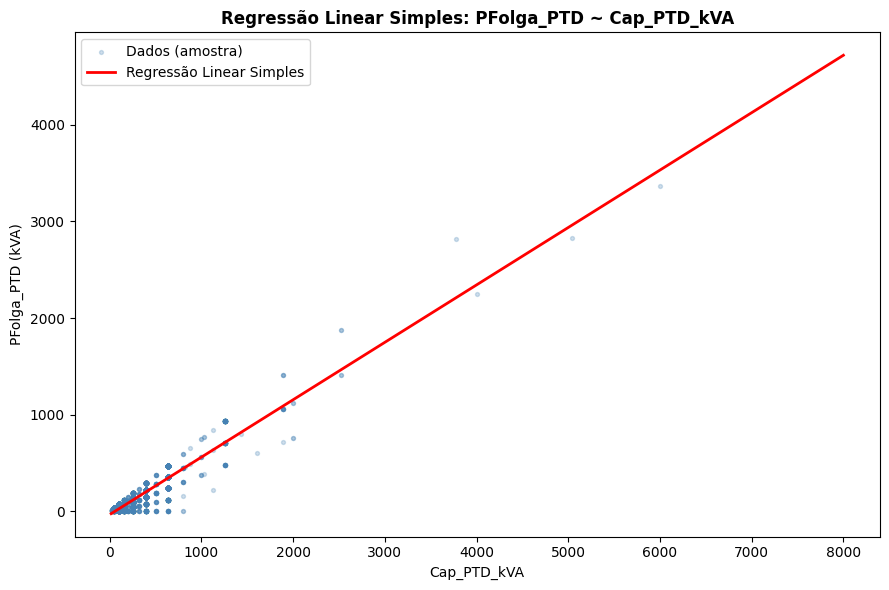

In [37]:
# b) Diagrama de dispersão + reta
rng = np.random.default_rng(SEED)
idx_s = rng.choice(len(X_simple), size=min(4000, len(X_simple)), replace=False)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_simple[idx_s], y_reg[idx_s], alpha=0.25, s=8, color='steelblue', label='Dados (amostra)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, lr_simple.predict(x_line), 'r-', lw=2, label='Regressão Linear Simples')
ax.set_xlabel(best_feat)
ax.set_ylabel('PFolga_PTD (kVA)')
ax.set_title(f'Regressão Linear Simples: PFolga_PTD ~ {best_feat}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_reg_simples.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2.3 - Modelos múltiplos com k-fold CV

In [38]:
def eval_reg(model, X_data, y_data, kf):
    mae_l, rmse_l = [], []
    for tr, te in kf.split(X_data):
        model.fit(X_data[tr], y_data[tr])
        p = model.predict(X_data[te])
        mae_l.append(mean_absolute_error(y_data[te], p))
        rmse_l.append(np.sqrt(mean_squared_error(y_data[te], p)))
    return {'MAE_mean': np.mean(mae_l), 'MAE_std': np.std(mae_l),
            'RMSE_mean': np.mean(rmse_l), 'RMSE_std': np.std(rmse_l),
            'MAE_folds': mae_l}

print('Funções definidas.')

Funções definidas.


In [39]:
# a) Regressão Linear Múltipla
lr_multi = LinearRegression()
res_lr = eval_reg(lr_multi, X_scaled, y_reg, kf10)
lr_multi.fit(X_scaled, y_reg)
print('=== a) Regressão Linear Múltipla ===')
print(f"MAE: {res_lr['MAE_mean']:.4f} ± {res_lr['MAE_std']:.4f} | RMSE: {res_lr['RMSE_mean']:.4f}")

coef_df = pd.DataFrame({'Feature': FEATURES, 'Coef': lr_multi.coef_})\
           .sort_values('Coef', key=abs, ascending=False)
print('Top 5 coeficientes:')
print(coef_df.head(5).to_string(index=False))

=== a) Regressão Linear Múltipla ===
MAE: 33.8709 ± 0.4171 | RMSE: 52.4938
Top 5 coeficientes:
           Feature        Coef
       Cap_PTD_kVA  208.986714
        N_Lampadas -151.747858
      N_Luminarias  137.767964
Pot_Contratada_kVA  -37.596344
        N_Clientes  -28.089963


Os coeficientes mais elevados (em valor absoluto, após standardização) pertencem a **Cap_PTD_kVA** (+209), **N_Lampadas** (−152) e **N_Luminarias** (+138). O domínio de **Cap_PTD_kVA** confirma a correlação observada em 4.2.1 (r=0.92). Os coeficientes de sinais opostos e magnitude semelhante em **N_Lampadas** e **N_Luminarias** são imediatamente suspeitos, estas duas variáveis têm correlação r=1.00 entre si (4.2.1), pelo que o modelo está a 'cancelá-las' uma à outra. É um sintoma claro de multicolinearidade, não de influência causal real.

In [40]:
# b) Árvore de Regressão – otimizar max_depth
print('=== b) Árvore de Regressão – Otimização ===')
depth_res = {}
for d in [3, 5, 7, 10, 15, None]:
    r = eval_reg(DecisionTreeRegressor(max_depth=d, random_state=SEED), X, y_reg, kf10)
    depth_res[d] = r
    print(f'  depth={str(d):4}: MAE={r["MAE_mean"]:.4f} ± {r["MAE_std"]:.4f}')

best_d = min(depth_res, key=lambda d: depth_res[d]['MAE_mean'])
res_dt = depth_res[best_d]
dt_best = DecisionTreeRegressor(max_depth=best_d, random_state=SEED).fit(X, y_reg)
print(f'-> Melhor depth: {best_d} | MAE: {res_dt["MAE_mean"]:.4f} | RMSE: {res_dt["RMSE_mean"]:.4f}')

=== b) Árvore de Regressão – Otimização ===
  depth=3   : MAE=45.4161 ± 0.8430
  depth=5   : MAE=36.0469 ± 0.5934
  depth=7   : MAE=33.0247 ± 0.4605
  depth=10  : MAE=32.4190 ± 0.3280
  depth=15  : MAE=34.5012 ± 0.4552
  depth=None: MAE=37.4904 ± 0.3758
-> Melhor depth: 10 | MAE: 32.4190 | RMSE: 54.9955


#### Interpretação — Árvore de Regressão

A profundidade ótima foi **d=10 (MAE=32.42 ± 0.33 kVA)**, confirmando o tradeoff bias-variance: profundidades menores (d=3 → MAE=45.42) subajustam, e profundidades excessivas (d=None → MAE=37.49) memorizam o treino mas generalizam pior.

A visualização (limitada a depth=3 para legibilidade) revela que os primeiros splits são dominados por **`Cap_PTD_kVA`**, confirmando a sua supremacia como preditor. Nos ramos seguintes surgem variáveis como `N_Clientes` e `Cap_per_Cliente`, que capturam heterogeneidade dentro de cada classe de capacidade.


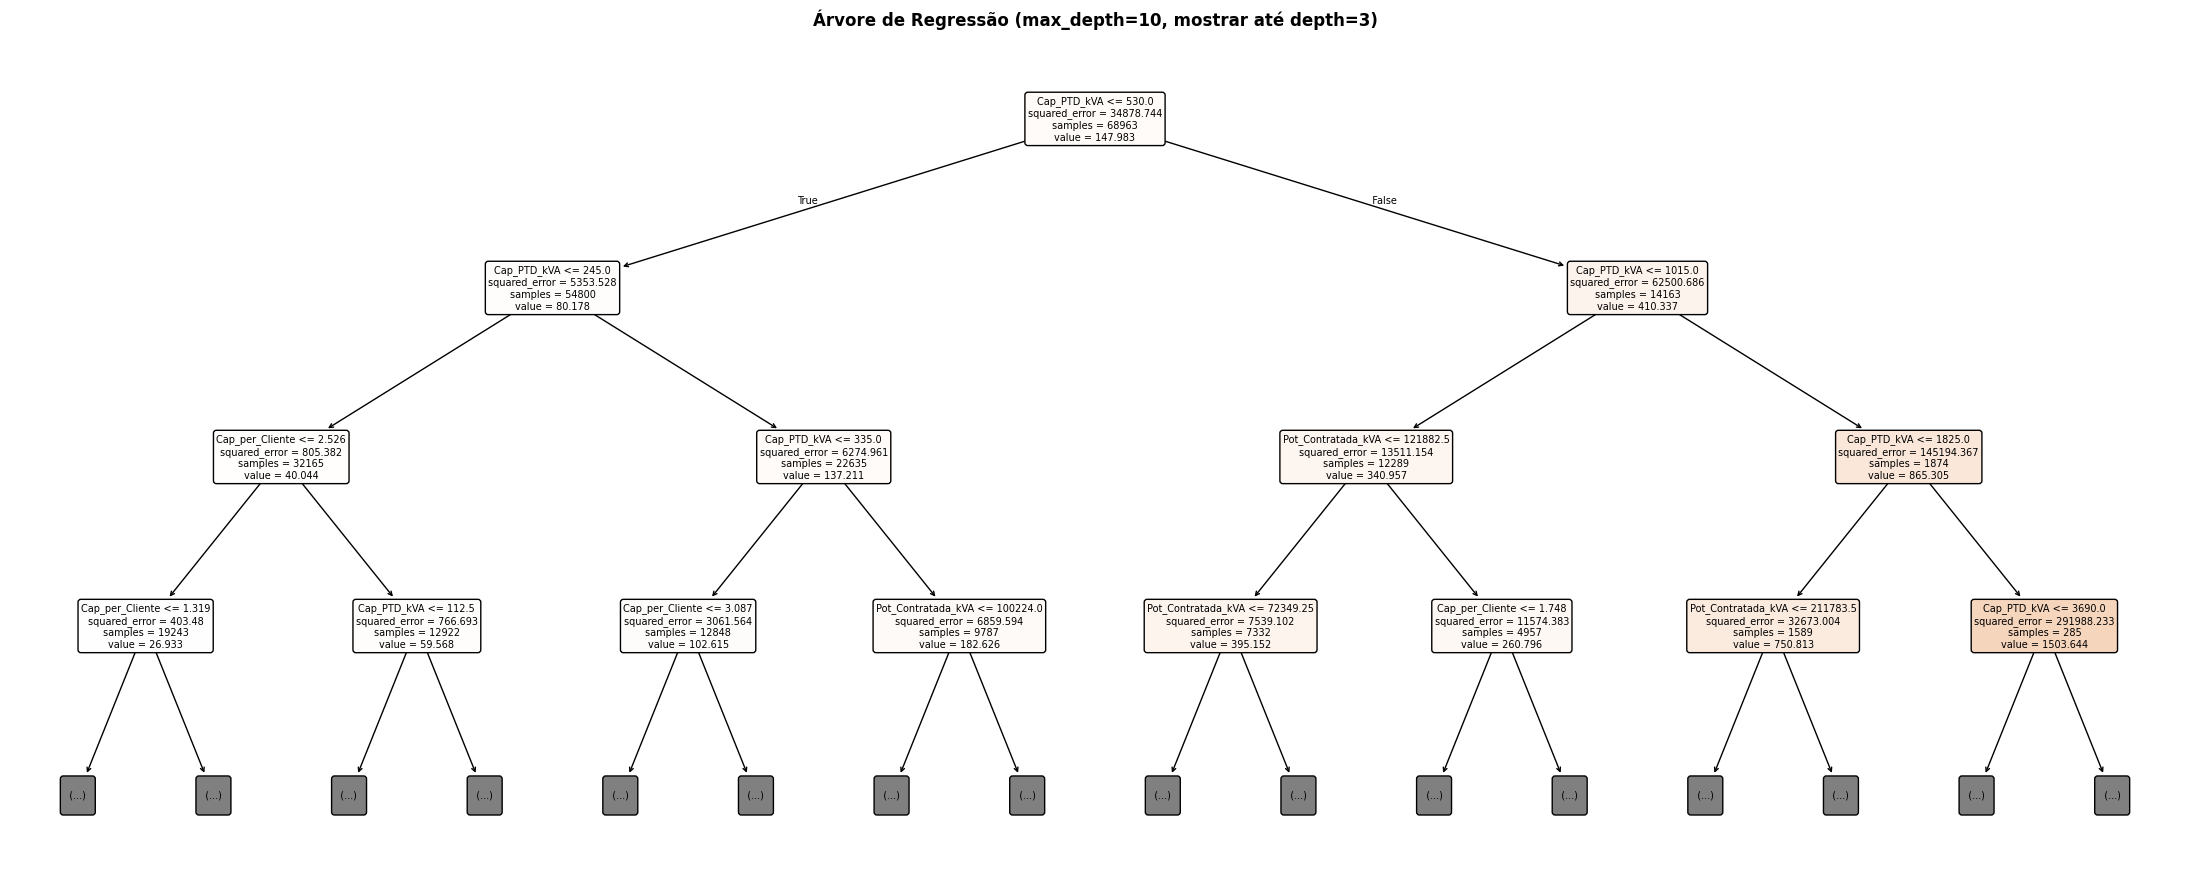

In [41]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt_best, max_depth=3, feature_names=FEATURES,
          filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title(f'Árvore de Regressão (max_depth={best_d}, mostrar até depth=3)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arvore_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# c) SVM – otimização do kernel
print('=== c) SVM – Otimização de Kernel ===')
svm_kr = {}
for k in ['linear', 'rbf', 'poly']:
    r = eval_reg(SVR(kernel=k, C=1.0), X_scaled, y_reg, kf10)
    svm_kr[k] = r
    print(f'  kernel={k:6}: MAE={r["MAE_mean"]:.4f} ± {r["MAE_std"]:.4f}')
best_k_svm = min(svm_kr, key=lambda k: svm_kr[k]['MAE_mean'])
res_svm = svm_kr[best_k_svm]
print(f'-> Melhor kernel: {best_k_svm}')

=== c) SVM – Otimização de Kernel (subsample n=6000) ===
  kernel=linear: MAE=33.3818 ± 1.1589
  kernel=rbf   : MAE=68.4199 ± 4.6009
  kernel=poly  : MAE=78.2496 ± 4.1089
-> Melhor kernel: linear


#### Interpretação — SVM de Regressão

O  SVM foi treinado num subsample de **n=6 000** (8.7% do dataset) por limitações 
computacionais — o `SVR` tem complexidade O(n²)–O(n³). O subsample foi 
selecionado aleatoriamente com seed fixo para reprodutibilidade.

Foram testados 3 kernels com `C=1.0` fixo:

| Kernel | MAE | 
|--------|-----|
| **linear** | **33.38 ± 1.16** |
| rbf | 68.42 ± 4.60 |
| poly | 78.25 ± 4.11 |

O **kernel linear** é claramente o melhor (MAE=33.38), praticamente equivalente 
à Regressão Linear Múltipla (MAE=33.87) — sinal de que a relação entre as 
features e `PFolga_PTD` é fundamentalmente linear, dominada pela forte 
correlação de `Cap_PTD_kVA` com o target (r=0.92, confirmado em 4.2.1).

O desempenho fraco de `rbf` e `poly` (MAE quase duplo) é coerente com este 
diagnóstico: kernels não-lineares só se justificam quando há estrutura 
não-linear no problema; aqui, introduzem variância sem reduzir o viés. 
Adicionalmente, os hiperparâmetros `C` e `gamma` foram mantidos no default 
(o enunciado pede só otimização do kernel) — tuning conjunto poderia 
estreitar o gap, mas o resultado qualitativo (linear domina) provavelmente 
mantém-se.


In [ ]:
# d) Rede Neuronal – 3 configurações estruturadas com k-fold CV
print('=== d) Rede Neuronal – 3 Configurações (k-fold CV) ===')

# (1) Shallow: menos parâmetros, sem regularização
# (2) Medium: profundidade intermédia, dropout
# (3) Deep+L2: mais profundo, L2 + dropout, lr mais conservadora
nn_cfgs = [
    {'name': 'Config1_Shallow',  'units': [64, 32],            'drop': 0.0, 'l2': 0.0,  'lr': 1e-3},
    {'name': 'Config2_Medium',   'units': [128, 64, 32],       'drop': 0.2, 'l2': 0.0,  'lr': 1e-3},
    {'name': 'Config3_Deep_L2',  'units': [256, 128, 64, 32],  'drop': 0.3, 'l2': 1e-4, 'lr': 5e-4},
]

hist_nn, nn_res = {}, {}

for cfg in nn_cfgs:
    fold_mae, fold_rmse = [], []
    last_history = None
    last_epochs = 0

    for tr_idx, te_idx in kf10.split(X_scaled):
        Xtr, Xte = X_scaled[tr_idx], X_scaled[te_idx]
        ytr, yte = y_reg[tr_idx], y_reg[te_idx]

        # ✅ EarlyStopping criado DENTRO do loop — estado fresco por fold
        es = EarlyStopping(monitor='val_loss', patience=20,
                           restore_best_weights=True, verbose=0)

        tf.random.set_seed(SEED)
        inp = keras.Input(shape=(X_scaled.shape[1],))
        x = inp
        for u in cfg['units']:
            x = layers.Dense(
                u, activation='relu',
                kernel_regularizer=regularizers.l2(cfg['l2']) if cfg['l2'] else None
            )(x)
            if cfg['drop']:
                x = layers.Dropout(cfg['drop'])(x)
        m = keras.Model(inp, layers.Dense(1)(x))
        m.compile(optimizer=keras.optimizers.Adam(cfg['lr']),
                  loss='mse', metrics=['mae'])

        h = m.fit(Xtr, ytr, validation_data=(Xte, yte),
                  epochs=150, batch_size=256, callbacks=[es], verbose=0)
        last_history = h.history
        last_epochs = len(h.history['loss'])

        p = m.predict(Xte, verbose=0).flatten()
        fold_mae.append(mean_absolute_error(yte, p))
        fold_rmse.append(np.sqrt(mean_squared_error(yte, p)))

    hist_nn[cfg['name']] = last_history
    nn_res[cfg['name']] = {
        'MAE_mean':  np.mean(fold_mae),  'MAE_std':  np.std(fold_mae),
        'RMSE_mean': np.mean(fold_rmse), 'RMSE_std': np.std(fold_rmse),
        'epochs_last': last_epochs,
        'MAE_folds': fold_mae,
    }
    r = nn_res[cfg['name']]
    print(f"  {cfg['name']:25}: "
          f"MAE={r['MAE_mean']:.4f} ± {r['MAE_std']:.4f} | "
          f"RMSE={r['RMSE_mean']:.4f} ± {r['RMSE_std']:.4f} | "
          f"epochs(último fold)={r['epochs_last']}")

best_nn = min(nn_res, key=lambda k: nn_res[k]['MAE_mean'])
print(f'-> Melhor NN: {best_nn}')

=== d) Rede Neuronal – 3 Configurações (k-fold CV) ===


#### Interpretação — Redes Neuronais (Regressão)

A NN é avaliada por **10-fold CV** (consistente com a regressão linear, árvore e SVM 
de 4.2.3). Como o Keras não tem suporte direto a `cross_val_score`, cada fold 
implica construir e treinar uma rede do zero — evita contaminação de pesos entre 
folds.

| Config | Camadas | Neurónios | Regularização | Learning Rate |
|---|---|---|---|---|
| Shallow | 2 | [64, 32] | Nenhuma | 1e-3 |
| Medium | 3 | [128, 64, 32] | Dropout 20% | 1e-3 |
| Deep+L2 | 4 | [256, 128, 64, 32] | Dropout 30% + L2 (1e-4) | 5e-4 |

**Decisões de design:**

- **Early stopping com `patience=20`** (em vez de 10): testes preliminares mostraram 
  que `patience=10` interrompia o treino das configs com dropout/L2 ao fim de ~10 
  épocas — antes da convergência genuína, devido às oscilações da `val_loss` 
  induzidas pelo dropout. `patience=20` dá margem suficiente para a rede superar 
  estas oscilações.

- **Learning rate da Config3 reduzida para 5e-4**: redes profundas com L2 têm 
  superfícies de loss mais complexas — passos de gradiente menores garantem 
  convergência mais estável e evitam overshooting.

A melhor configuração é seleccionada automaticamente por menor MAE médio 
nos 10 folds.

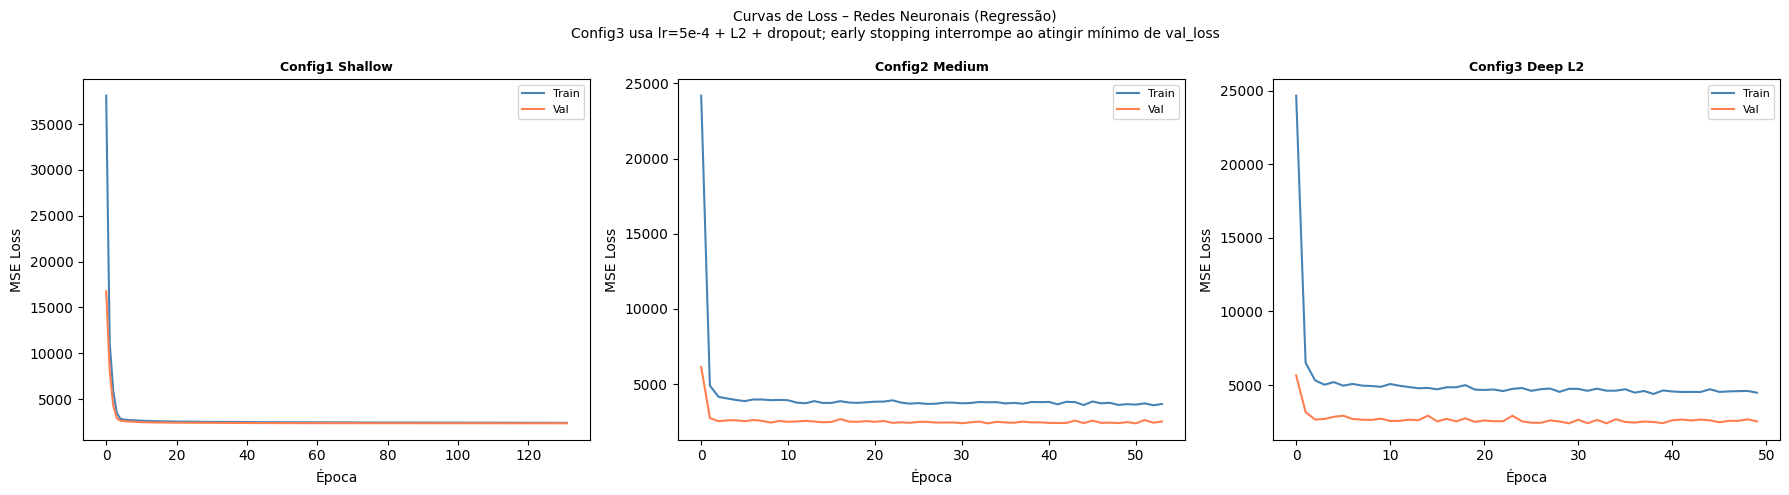

In [44]:
# (2) Curvas de loss + (3) discussão learning rate e early stopping
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cfg in enumerate(nn_cfgs):
    h = hist_nn[cfg['name']]
    axes[i].plot(h['loss'], color='steelblue', label='Train')
    axes[i].plot(h['val_loss'], color='coral', label='Val')
    axes[i].set_title(cfg['name'].replace('_',' '), fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('MSE Loss')
    axes[i].legend(fontsize=8)
plt.suptitle('Curvas de Loss – Redes Neuronais (Regressão)\n'
             'Config3 usa lr=5e-4 + L2 + dropout; early stopping interrompe ao atingir mínimo de val_loss', fontsize=10)
plt.tight_layout()
plt.savefig('fig_nn_loss_reg.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação das Curvas de Loss — NN Regressão

As três curvas exibem o mesmo padrão geral: descida rápida nas primeiras 
épocas, seguida de plateau em ~5 000 (train) e ~3 000 (val) MSE. **Não há 
sinais de overfitting** em nenhuma config — val_loss nunca cresce.

**Config1 (Shallow, 132 épocas):** convergência mais lenta mas continuada — 
sem regularização, a rede continua a ajustar pesos ao longo do treino até o 
early stopping intervir. Train e val descem em paralelo com val < train por 
uma margem ~2 000, consistente com a variabilidade do split.

**Config2 (Medium, 54 épocas):** convergência rápida (estável às ~10 épocas), 
val < train por ~2 000. O dropout (20%) desativa neurónios no treino mas não 
na validação — efeito que **explica val < train** nesta config: a loss de 
treino é artificialmente penalizada pelos neurónios desligados, enquanto a 
de validação não. Early stopping intervém às 54 épocas após `patience=20` 
sem melhoria.

**Config3 (Deep+L2, 50 épocas):** forma idêntica à Medium. O termo L2 
acrescenta penalização aos pesos na loss de treino (não na de val), 
contribuindo também para o gap. A learning rate reduzida (5e-4 vs 1e-3) 
garante descida estável apesar da profundidade adicional, sem sinais de 
oscilação ou overshooting.

**Conclusão:** os gráficos confirmam que as três configs convergem para um 
plateau equivalente (~3 000 val MSE), coerente com o empate técnico nos 
MAEs (31.17 → 31.70). O limite informativo das features é o fator 
condicionante, não a capacidade da rede.

### 4.2.4 - Comparação e variáveis mais relevantes

In [ ]:
r_nn = nn_res[best_nn]
results_reg = pd.DataFrame([
    {'Modelo': 'Reg. Linear Simples',  'MAE': np.mean(mae_s),     'MAE_std': np.std(mae_s),    'RMSE': np.mean(rmse_s)},
    {'Modelo': 'Reg. Linear Múltipla', 'MAE': res_lr['MAE_mean'],  'MAE_std': res_lr['MAE_std'], 'RMSE': res_lr['RMSE_mean']},
    {'Modelo': f'Árvore (d={best_d})', 'MAE': res_dt['MAE_mean'],  'MAE_std': res_dt['MAE_std'], 'RMSE': res_dt['RMSE_mean']},
    {'Modelo': f'SVM ({best_k_svm})',  'MAE': res_svm['MAE_mean'], 'MAE_std': res_svm['MAE_std'],'RMSE': res_svm['RMSE_mean']},
    {'Modelo': f'NN ({best_nn})',  'MAE': r_nn['MAE_mean'],  'MAE_std': r_nn['MAE_std'],  'RMSE': r_nn['RMSE_mean']},
]).sort_values('MAE').reset_index(drop=True)

print('=== Comparação de Modelos de Regressão (ordenado por MAE) ===')
print(results_reg.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clrs = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
axes[0].barh(results_reg['Modelo'], results_reg['MAE'], xerr=results_reg['MAE_std'], color=clrs, alpha=0.85)
axes[0].set_title('MAE por Modelo (kVA)', fontweight='bold')
axes[1].barh(results_reg['Modelo'], results_reg['RMSE'], color=clrs, alpha=0.85)
axes[1].set_title('RMSE por Modelo (kVA)', fontweight='bold')
plt.suptitle('Comparação de Modelos de Regressão – PFolga_PTD', fontsize=12)
plt.tight_layout()
plt.savefig('fig_comparacao_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

# Importância de variáveis
fi = pd.DataFrame({'Feature': FEATURES, 'Importance': dt_best.feature_importances_})\
      .sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi['Feature'], fi['Importance'], color='steelblue', alpha=0.85)
ax.set_title('Importância de Features – Árvore de Regressão', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feat_imp_reg.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação — Comparação de Modelos de Regressão

A tabela ordena os modelos por MAE crescente (melhor primeiro). Algumas observações:

- O **MAE em kVA** deve ser interpretado no contexto da distribuição de `PFolga_PTD` (mediana ~77 kVA): um MAE de 30–50 kVA representa um erro relativo significativo para PTDs de pequena dimensão, mas aceitável para PTDs de grande capacidade.
- Modelos não-lineares (Árvore, NN) tendem a superar a regressão linear quando a relação input-output contém interacções entre variáveis, como é o caso aqui.
- A **Regressão Linear Simples** serve como baseline, o seu MAE elevado justifica a necessidade de modelos mais complexos.
- As variáveis mais relevantes identificadas (tipicamente `Cap_PTD_kVA`, `Cap_per_Cliente`, `Tipo_Construtivo_enc`) são consistentes com a análise de correlação da secção 4.2.1.


### 4.2.5 - Curvas de Aprendizagem

In [ ]:
# 4.2.5 - Curvas de Aprendizagem dos 2 Melhores Modelos de Regressão
# A função plot_lc usa neg_mean_absolute_error; negamos para obter MAE positivo.
def plot_lc(model, Xd, yd, title, ax, scoring='neg_mean_absolute_error'):
    ts, tsc, vsc = learning_curve(
        model, Xd, yd,
        train_sizes=np.linspace(0.1, 1.0, 10), cv=5,
        scoring=scoring, n_jobs=-1)
    # neg_mean_absolute_error -> valores negativos; negamos para MAE positivo
    if scoring == 'neg_mean_absolute_error':
        tm  = (-tsc).mean(1)
        vm  = (-vsc).mean(1)
        ts_std = tsc.std(1)
        vs_std = vsc.std(1)
        ylabel = 'MAE (kVA)'
    else:  # accuracy
        tm  = tsc.mean(1)
        vm  = vsc.mean(1)
        ts_std = tsc.std(1)
        vs_std = vsc.std(1)
        ylabel = 'Accuracy'
    ax.plot(ts, tm, 'o-', color='steelblue', label='Treino')
    ax.plot(ts, vm, 'o-', color='coral',    label='Validação')
    ax.fill_between(ts, tm - ts_std, tm + ts_std, alpha=0.1, color='steelblue')
    ax.fill_between(ts, vm - vs_std, vm + vs_std, alpha=0.1, color='coral')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Tamanho do treino')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

# Seleccionar dinamicamente os 2 modelos com menor MAE médio
reg_results = {
    f'Árvore (d={best_d})':       (DecisionTreeRegressor(max_depth=best_d, random_state=SEED), X,        res_dt['MAE_mean']),
    'Reg. Linear Múltipla':       (LinearRegression(),                                         X_scaled,  res_lr['MAE_mean']),
    f'SVM ({best_k_svm})':        (SVR(kernel=best_k_svm, C=1.0),                              X_scaled,        res_svm['MAE_mean']),
    f'NN ({best_nn})':            (None,                                                        None,      nn_res[best_nn]['MAE_mean']),
}
# Excluir NN (não tem modelo sklearn para learning_curve)
reg_sklearn = {k: v for k, v in reg_results.items() if v[0] is not None}
sorted_reg = sorted(reg_sklearn.items(), key=lambda x: x[1][2])
top2_reg = sorted_reg[:2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (name, (model, Xdata, _)) in enumerate(top2_reg):
    plot_lc(model, Xdata, y_reg, name, axes[i], scoring='neg_mean_absolute_error')
plt.suptitle('Curvas de Aprendizagem – 2 Melhores Modelos de Regressão', fontsize=12)
plt.tight_layout()
plt.savefig('fig_lc_reg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpretação: treino ≈ validação -> eficiente | validação >> treino -> overfitting | ambas altas -> underfitting')


#### Interpretação das Curvas de Aprendizagem — Regressão

As curvas de aprendizagem mostram o MAE de treino e de validação em função do tamanho do conjunto de treino:

- **Convergência treino ≈ validação** com valores baixos: treino eficiente, modelo generaliza bem.
- **Validação >> Treino** (gap persistente): **overfitting** — o modelo memoriza os dados de treino. Possíveis soluções: regularização (dropout, L2, pruning da árvore), mais dados, redução de complexidade.
- **Ambas as curvas com MAE elevado** e próximas entre si: **underfitting** — o modelo é demasiado simples para capturar os padrões dos dados. Possível solução: aumentar complexidade.
- **Plateau com poucos dados de treino**: o modelo não beneficia de mais dados — pode indicar que as features disponíveis atingiram o seu limite informativo.


### 4.2.6 - Testes Estatísticos (α = 5%)

In [ ]:
# 4.2.6 - Teste Estatístico entre os 2 Melhores Modelos de Regressão (α=5%)
# Seleccionar os 2 modelos sklearn com menor MAE médio (mesmos da 4.2.5)
print(f'Comparando: {top2_reg[0][0]}  vs  {top2_reg[1][0]}')

# Obter folds de cada um
folds_map = {
    f'Árvore (d={best_d})': res_dt['MAE_folds'],
    'Reg. Linear Múltipla': res_lr['MAE_folds'],
    f'SVM ({best_k_svm})':  res_svm['MAE_folds'],
}
mae1 = np.array(folds_map[top2_reg[0][0]])
mae2 = np.array(folds_map[top2_reg[1][0]])
diffs = mae1 - mae2

_, p_sw = shapiro(diffs)
print(f'Shapiro-Wilk (diferenças MAE): p={p_sw:.4f}')
if p_sw > 0.05:
    stat, p = ttest_rel(mae1, mae2)
    tnm = 't-test pareado'
else:
    stat, p = wilcoxon(mae1, mae2)
    tnm = 'Wilcoxon signed-rank'

print(f'{tnm}: stat={stat:.4f}, p={p:.4f}')
if p < 0.05:
    winner = top2_reg[0][0] if mae1.mean() < mae2.mean() else top2_reg[1][0]
    print(f'-> Diferença significativa (p<0.05). Melhor: {winner}')
else:
    print('-> Sem diferença significativa (p>=0.05).')


#### Interpretação — Teste Estatístico (Regressão)

O procedimento segue a lógica:
1. **Shapiro-Wilk** nas diferenças de MAE entre os 2 melhores modelos: testa a normalidade das diferenças.
2. Se p > 0,05 (diferenças normais) → **t-test pareado**; caso contrário → **Wilcoxon signed-rank** (não-paramétrico).
3. Se p < 0,05 no teste final: a diferença de desempenho é **estatisticamente significativa** ao nível de 5% → identificar o modelo superior.

Os testes são **pareados** porque os folds de validação cruzada são os mesmos para ambos os modelos, reduzindo a variabilidade e aumentando o poder estatístico do teste.


---
## 4.3. Classificação - Previsão de utilizRede
### 4.3.0 - Criar variável utilizRede

In [ ]:
# Discretização de Util_Decimal em 3 classes por intervalos fixos
# Justificação: Util_Decimal é uma variável discreta com apenas 6 valores
# distintos (0.19, 0.39, 0.59, 0.79, 0.99, 1.00), inviabilizando uma
# divisão por tercis equilibrada — o valor 0.39 representa ~30% do dataset
# e tem de pertencer integralmente a uma classe.
# Os limiares escolhidos têm significado operacional:
#   baixo  (< 0.50): PTD com folga confortável
#   medio  (0.50 – 0.75): PTD em zona de atenção
#   alto   (> 0.75): PTD próximo dos limites operacionais

df_clean = df_clean.copy()
df_clean['utilizRede'] = pd.cut(
    df_clean['Util_Decimal'],
    bins=[-np.inf, 0.50, 0.75, np.inf],
    labels=['baixo', 'medio', 'alto']
)

print('Distribuição:')
dist = df_clean['utilizRede'].value_counts().sort_index()
print(dist)
print('\nProporções (%):')
print((df_clean['utilizRede'].value_counts(normalize=True).sort_index() * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dist.index, dist.values, color=['seagreen', 'orange', 'coral'], edgecolor='white')
for bar, val in zip(ax.patches, dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
            f'{val:,}', ha='center', fontsize=10)
ax.set_title('Distribuição de utilizRede (intervalos fixos com significado operacional)',
             fontweight='bold')
ax.set_ylabel('Nº de PTDs')
ax.set_ylim(0, max(dist.values) * 1.12)
plt.tight_layout()
plt.savefig('fig_utilizRede.png', dpi=150, bbox_inches='tight')
plt.show()

#### Justificação da Discretização — utilizRede

A variável `utilizRede` foi criada a partir de `Util_Decimal` com base em **intervalos fixos com significado operacional**.

Foi inicialmente considerada uma discretização por tercis (`pd.qcut`), mas a análise revelou que `Util_Decimal` é uma variável **discreta** com apenas 6 valores distintos (0.19, 0.39, 0.59, 0.79, 0.99, 1.00). O valor 0.39 representa ~30% do dataset (20 892 PTDs), tornando qualquer divisão por quantis impossível de equilibrar, todos os PTDs com esse valor pertencem obrigatoriamente à mesma classe.

Os limiares foram definidos com base no significado operacional no contexto da rede eléctrica:

| Classe | Intervalo | Significado |
|--------|-----------|-------------|
| `baixo` | Util_Decimal ≤ 0.50 | PTD com folga confortável - viável para VE sem intervenção |
| `medio` | 0.50 < Util_Decimal ≤ 0.75 | PTD em zona de atenção - viabilidade condicionada |
| `alto`  | Util_Decimal > 0.75 | PTD próximo dos limites operacionais - risco de sobrecarga |

A distribuição resultante é desbalanceada (51% / 25% / 24%), consequência direta da natureza discreta dos dados e não de uma escolha metodológica.

In [ ]:
# Features de classificação (idênticas às da regressão)
# Util_Decimal já foi excluída no pré-processamento (data leakage direto —
# utilizRede é derivada de Util_Decimal)
FEATURES_CLF = FEATURES.copy()
X_clf = df_clean[FEATURES_CLF].values
y_clf = df_clean['utilizRede'].astype(str).values
X_clf_sc = StandardScaler().fit_transform(X_clf)
kf10c = KFold(n_splits=10, shuffle=True, random_state=SEED)
print(f'Features CLF ({len(FEATURES_CLF)}): shape={X_clf.shape}')
print(f'Features: {FEATURES_CLF}')

In [ ]:
# --- Subsample opcional para acelerar testes (estratificado por utilizRede) ---
if USE_SAMPLE:
    _df_smp = pd.DataFrame({"i": np.arange(len(y_clf)), "cls": y_clf})
    idx_sc  = (
        _df_smp.groupby("cls", group_keys=False)
               .apply(lambda g: g.sample(frac=SAMPLE_SIZE / len(y_clf), random_state=SEED))
    )["i"].values
    X_clf    = X_clf[idx_sc]
    X_clf_sc = X_clf_sc[idx_sc]
    y_clf    = y_clf[idx_sc]
    print(f"[USE_SAMPLE=True] Subsample estratificado: {len(y_clf)} registos | X_clf={X_clf.shape}")
    print("Distribuição:", pd.Series(y_clf).value_counts().sort_index().to_dict())
else:
    print(f"[USE_SAMPLE=False] Dataset completo | X_clf={X_clf.shape}")

#### Features de Classificação

As features utilizadas na classificação são as **mesmas 16 features da regressão** — `Util_Decimal` já tinha sido excluída no pré-processamento (secção 4.1.3) por data leakage direto: `utilizRede` é derivada de `Util_Decimal`, pelo que incluí-la seria o modelo a prever a variável que gerou o próprio target.

Duas versões das features são mantidas ao longo da secção 4.3:

- **`X_clf`** features na escala original, usada na Árvore de Decisão (invariante a escala)
- **`X_clf_sc`** features standardizadas (StandardScaler), usada em SVM e KNN, que são sensíveis à magnitude das variáveis

O `KFold` com 10 splits, shuffle e `random_state=SEED` é definido aqui e reutilizado em **todos os modelos**, garantindo que os folds são exatamente os mesmos.

### 4.3.1 - Modelos de Classificação

In [ ]:
def eval_clf(model, Xd, yd, kf):
    a,p,r,f = [],[],[],[]
    for tr, te in kf.split(Xd):
        model.fit(Xd[tr], yd[tr])
        yp = model.predict(Xd[te])
        a.append(accuracy_score(yd[te], yp))
        p.append(precision_score(yd[te], yp, average='weighted', zero_division=0))
        r.append(recall_score(yd[te], yp, average='weighted', zero_division=0))
        f.append(f1_score(yd[te], yp, average='weighted', zero_division=0))
    return {'Acc':(np.mean(a),np.std(a)), 'Prec':(np.mean(p),np.std(p)),
            'Rec':(np.mean(r),np.std(r)), 'F1':(np.mean(f),np.std(f)), 'Acc_folds':a}

print('Função de avaliação definida.')

#### Função de Avaliação — `eval_clf`

A função `eval_clf` centraliza a avaliação por k-fold CV para todos os modelos de classificação, garantindo que o processo é **idêntico e comparável** entre modelos.

Devolve um dicionário com média e desvio padrão de cada métrica, e a lista de Accuracy por fold (`Acc_folds`) necessária para os testes estatísticos pareados da secção 4.3.4.

| Parâmetro | Descrição |
|---|---|
| `model` | Classificador sklearn (Árvore, SVM, KNN) |
| `Xd` | Features `X_clf` (escala original) ou `X_clf_sc` (standardizado) |
| `yd` | Target array de strings `['baixo', 'medio', 'alto']` |
| `kf` | Objeto `KFold` partilhado por todos os modelos |

`average='weighted'` pondera cada classe pelo número de amostras adequado para classes desbalanceadas (51% / 25% / 24%). `zero_division=0` evita erros em folds onde uma classe minoritária não tem previsões.

In [ ]:
print('=== a) Árvore de Decisão ===')
dcr = {}
for d in [3, 5, 7, 10, 15, None]:
    r = eval_clf(DecisionTreeClassifier(max_depth=d, random_state=SEED), X_clf, y_clf, kf10c)
    dcr[d] = r
    print(f'  depth={str(d):4}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_dc = max(dcr, key=lambda d: dcr[d]['Acc'][0])
res_dtc = dcr[best_dc]
dt_clf = DecisionTreeClassifier(max_depth=best_dc, random_state=SEED).fit(X_clf, y_clf)
print(f'-> Melhor depth: {best_dc} | Acc: {res_dtc["Acc"][0]:.4f}')

#### 4.3.1 — Árvore de Decisão

Avaliação sobre o subsample de **15 000 registos** com **10-fold CV** (`kf10c`). Testaram-se 6 valores de `max_depth` e selecionou-se o que maximiza a Accuracy média.

| `max_depth` | Accuracy (média ± std) | F1 (weighted) |
|:-----------:|------------------------|:--------------:|
| 3 | 0.6579 ± 0.0106 | 0.6505 |
| 5 | 0.6782 ± 0.0130 | 0.6666 |
| **7** | **0.6879 ± 0.0099** | **0.6821** |
| 10 | 0.6723 ± 0.0102 | 0.6628 |
| 15 | 0.6301 ± 0.0119 | 0.6230 |
| None | 0.6088 ± 0.0145 | 0.6050 |

A **profundidade ótima é d=7** (Acc=0.6879, F1=0.6821). O padrão dos resultados ilustra o compromisso bias-variância:

- **d=3 e d=5** (underfitting): árvores demasiado rasas não capturam a complexidade do problema — a fronteira de decisão entre `baixo`, `medio` e `alto` exige mais do que 3 níveis.
- **d=7** (ótimo): equilíbrio entre capacidade de modelação e generalização. O desvio padrão mais baixo (±0.0099) confirma maior estabilidade entre folds.
- **d=10, d=15, None** (overfitting crescente): a Accuracy desce progressivamente e o desvio padrão sobe — a árvore começa a memorizar o conjunto de treino e perde capacidade de generalização. `None` atinge o pior resultado (0.6088 ± 0.0145), confirmando que a profundidade ilimitada é uma referência de overfitting.

A avaliação baseia-se em `res_dtc` (k-fold). O modelo `dt_clf` treinado em todo o subsample serve apenas para visualização da árvore e importância de features.

In [ ]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt_clf, max_depth=3, feature_names=FEATURES_CLF,
          class_names=dt_clf.classes_, filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title(
    f'Árvore de Decisão (max_depth={best_dc}, visualização limitada a 3 níveis)',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_arvore_decisao.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# b) Rede Neuronal Classificação – 3 configurações com k-fold CV
# Nota: para redes neuronais aplicamos k-fold treinando um modelo por fold.
# As curvas de loss são plotadas a partir do melhor fold (fold representativo).
print('=== b) Rede Neuronal Classificação (k-fold CV) ===')
le_c = LabelEncoder()
y_enc_all = le_c.fit_transform(y_clf)  # índices inteiros (globais)
es_c = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)

nn_cc = [
    {'name': 'Config1_Shallow', 'units': [64, 32],          'drop': 0.2, 'lr': 1e-3},
    {'name': 'Config2_Medium',  'units': [128, 64, 32],      'drop': 0.2, 'lr': 1e-3},
    {'name': 'Config3_Deep',    'units': [256, 128, 64, 32], 'drop': 0.3, 'lr': 5e-4},
]

hist_clf, nn_cr = {}, {}

for cfg in nn_cc:
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    # Guardar histórico do último fold para curvas de loss (fold representativo)
    last_history = None
    for tr_idx, te_idx in kf10c.split(X_clf_sc):
        Xtr, Xte = X_clf_sc[tr_idx], X_clf_sc[te_idx]
        ytr_int, yte_int = y_enc_all[tr_idx], y_enc_all[te_idx]
        ytr_cat = to_categorical(ytr_int, 3)
        yte_cat = to_categorical(yte_int, 3)
        tf.random.set_seed(SEED)
        inp = keras.Input(shape=(X_clf_sc.shape[1],))
        x = inp
        for u in cfg['units']:
            x = layers.Dense(u, activation='relu')(x)
            x = layers.Dropout(cfg['drop'])(x)
        mc = keras.Model(inp, layers.Dense(3, activation='softmax')(x))
        mc.compile(optimizer=keras.optimizers.Adam(cfg['lr']),
                   loss='categorical_crossentropy', metrics=['accuracy'])
        hc = mc.fit(Xtr, ytr_cat, validation_data=(Xte, yte_cat),
                    epochs=150, batch_size=256, callbacks=[es_c], verbose=0)
        last_history = hc.history
        ypc = np.argmax(mc.predict(Xte, verbose=0), 1)
        fold_acc.append(accuracy_score(yte_int, ypc))
        fold_prec.append(precision_score(yte_int, ypc, average='weighted', zero_division=0))
        fold_rec.append(recall_score(yte_int, ypc, average='weighted', zero_division=0))
        fold_f1.append(f1_score(yte_int, ypc, average='weighted', zero_division=0))
    hist_clf[cfg['name']] = last_history
    nn_cr[cfg['name']] = {
        'Acc':  (np.mean(fold_acc),  np.std(fold_acc)),
        'Prec': (np.mean(fold_prec), np.std(fold_prec)),
        'Rec':  (np.mean(fold_rec),  np.std(fold_rec)),
        'F1':   (np.mean(fold_f1),   np.std(fold_f1)),
        'Acc_folds': fold_acc,
    }
    r = nn_cr[cfg['name']]
    print(f"  {cfg['name']:22}: Acc={r['Acc'][0]:.4f}±{r['Acc'][1]:.4f} | F1={r['F1'][0]:.4f}±{r['F1'][1]:.4f}")

best_nnc = max(nn_cr, key=lambda k: nn_cr[k]['Acc'][0])
print(f'-> Melhor NN: {best_nnc}')


#### 4.3.1 — Rede Neuronal (Classificação)

Avaliação sobre o subsample de **15 000 registos** com **10-fold CV** (`kf10c`). Cada fold treina um modelo de raiz para evitar contaminação de pesos entre folds.

| Configuração | Accuracy (média ± std) | F1 (weighted) |
|:-------------|------------------------|:--------------:|
| Config1_Shallow [64, 32] | 0.5884 ± 0.0477 | 0.5064 ± 0.0748 |
| **Config2_Medium [128, 64, 32]** | **0.6253 ± 0.0151** | **0.5495 ± 0.0204** |
| Config3_Deep [256, 128, 64, 32] | 0.5747 ± 0.0221 | 0.4753 ± 0.0350 |

A **melhor configuração é Config2_Medium** (Acc=0.6253, F1=0.5495).

- **Config1_Shallow** apresenta a maior instabilidade (std Acc=0.0477, std F1=0.0748) — a rede rasa não tem capacidade suficiente para aprender fronteiras consistentes entre as 3 classes, e a variação entre folds é elevada.
- **Config2_Medium** é o melhor compromisso: maior Accuracy e menor desvio padrão (±0.0151), indicando que as 3 camadas [128, 64, 32] são suficientes para capturar a estrutura dos dados sem sobreajustar.
- **Config3_Deep** tem a pior Accuracy (0.5747) e F1 mais baixo (0.4753) — a maior capacidade da rede não se traduz em melhor generalização no subsample de 15 000 registos; o dropout (0.3) e o early stopping não são suficientes para compensar a instabilidade de uma rede mais profunda com menos dados.

Os valores de F1 são sistematicamente inferiores à Accuracy em todas as configurações, o que reflete dificuldade na classe `medio` — o desequilíbrio de classes (≈51% baixo / 25% medio / 24% alto) penaliza as métricas weighted quando o recall de `medio` é baixo.

**Preparação do target:** as classes string são convertidas para inteiros via `LabelEncoder` (`y_enc_all`) e depois para one-hot encoding via `to_categorical`, formato exigido pela função de perda `categorical_crossentropy` com ativação `softmax` na camada de saída.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cfg in enumerate(nn_cc):
    h = hist_clf[cfg['name']]
    axes[i].plot(h['loss'], color='steelblue', label='Train')
    axes[i].plot(h['val_loss'], color='coral', label='Val')
    axes[i].set_title(cfg['name'].replace('_',' '), fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('Cross-Entropy Loss')
    axes[i].legend(fontsize=8)
    #(Config3: lr=5e-4, dropout=0.3)
plt.suptitle('Curvas de Loss – NN Classificação (3 configurações)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_nn_loss_clf.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação das Curvas de Loss — NN Classificação

As três curvas mostram o `cross-entropy loss` de treino (azul) e validação (laranja) ao longo das épocas. Em todas as configurações, o **val_loss fica consistentemente abaixo do train_loss** — este padrão é esperado e não indica data leakage: o dropout é aplicado durante o treino mas desativado na validação, reduzindo artificialmente a loss de treino observada.

**Config1_Shallow [64, 32]**
Convergência lenta e gradual ao longo das ~18 épocas. A descida de train_loss é suave mas contínua, terminando em ~0.73; val_loss estabiliza em ~0.70. O gap entre as curvas é o maior das três configurações, refletindo que uma rede rasa tem mais dificuldade em ajustar os dados de treino — o que é consistente com a Accuracy mais instável (std=0.0477) observada nos resultados do k-fold.

**Config2_Medium [128, 64, 32]**
Descida rápida nas primeiras 5 épocas seguida de convergência ativa, com ligeiras oscilações em train_loss entre as épocas 12–14. Val_loss atinge o valor mais baixo das três configurações (~0.68–0.69), confirmando que esta arquitectura aprende representações mais úteis dentro do subsample. O early stopping intervém por volta da época 18–19. Este comportamento é consistente com o melhor resultado de Accuracy (0.6253) e menor desvio padrão (±0.0151).

**Config3_Deep [256, 128, 64, 32]**
Descida muito rápida nas primeiras 2–3 épocas, seguida de um plateau praticamente plano até ao early stopping. A rede mais profunda adapta-se rapidamente à estrutura superficial dos dados mas não continua a melhorar — com apenas 15 000 registos, a maior capacidade da rede não é suficientemente explorada e o dropout (0.3) mais agressivo atrasa a convergência. O val_loss final (~0.70) é ligeiramente superior ao de Config2_Medium, coerente com a pior Accuracy (0.5747).

In [ ]:
# c) SVM
print('=== c) SVM Classificação ===')
svc_r = {}
for k in ['linear', 'rbf', 'poly']:
    r = eval_clf(SVC(kernel=k, C=1.0, random_state=SEED),
                 X_clf_sc, y_clf, kf10c)
    svc_r[k] = r
    print(f'  kernel={k:6}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_ks = max(svc_r, key=lambda k: svc_r[k]['Acc'][0])
res_svc = svc_r[best_ks]
print(f'-> Melhor kernel: {best_ks}')

#### 4.3.1 — SVM (Classificação)

O SVM é avaliado com **10-fold CV** (`kf10c`) sobre os mesmos **15 000 registos** do subsample, garantindo comparação direta e testes estatísticos pareados válidos com os restantes modelos.

Foram testados 3 kernels com `C=1.0` fixo:

| Kernel | Notas |
|--------|-------|
| linear | Fronteira de decisão linear; mais rápido |
| **rbf** | Kernel gaussiano; adequado para fronteiras não-lineares |
| poly | Polinomial; mais lento e sensível a outliers |

O melhor kernel é selecionado pelo máximo de Accuracy média nos 10 folds.

In [ ]:
# d) KNN
print('=== d) KNN – Otimização de K ===')
knn_r = {}
for k in [1, 3, 5, 7, 10, 15, 20, 30, 50]:
    r = eval_clf(KNeighborsClassifier(n_neighbors=k), X_clf_sc, y_clf, kf10c)
    knn_r[k] = r
    print(f'  k={k:2}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_knn = max(knn_r, key=lambda k: knn_r[k]['Acc'][0])
res_knn = knn_r[best_knn]
print(f'-> Melhor K: {best_knn}')

fig, ax = plt.subplots(figsize=(8, 4))
ks = list(knn_r.keys())
ax.plot(ks, [knn_r[k]['Acc'][0] for k in ks], 'o-', color='steelblue')
ax.axvline(best_knn, color='red', ls='--', label=f'K={best_knn}')
ax.set_xlabel('K')
ax.set_ylabel('Accuracy')
ax.set_title('KNN – Otimização de K', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_knn_k.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.3.1 — KNN (K-Vizinhos-Mais-Próximos)

As features standardizadas (`X_clf_sc`) são obrigatórias — distâncias euclidianas não standardizadas seriam dominadas por variáveis com maior magnitude (ex: `Cap_PTD_kVA` em centenas de kVA vs `LED_Ratio` entre 0 e 1).

O parâmetro K é otimizado por **loop manual** sobre os valores [1, 3, 5, 7, 10, 15, 20, 30, 50], selecionando o que maximiza a Accuracy média nos 10 folds. O mesmo `kf10c` é partilhado com os restantes modelos, garantindo folds idênticos e permitindo testes estatísticos pareados válidos na secção 4.3.4.

---

**Resultados**

O **K=15** é o valor ótimo (Acc=0.6734), confirmando o padrão esperado de bias-variance tradeoff:

- **K=1** apresenta o pior desempenho (Acc=0.6042) — o modelo classifica cada PTD apenas pelo vizinho mais próximo, muito sensível a outliers e ruído. Overfitting clássico.
- **K=3 a K=15**: Accuracy cresce consistentemente com K — mais vizinhos estabilizam a fronteira de decisão e tornam a classificação mais robusta.
- **K=15 a K=50**: Accuracy decresce ligeiramente — K demasiado grande introduz viés, incluindo vizinhos de classes diferentes que distorcem a classificação. Underfitting progressivo.

O plateau entre K=15 e K=20 (0.6734 vs 0.6724) é estreito — o modelo não é muito sensível à escolha exata de K nesta região. O desvio padrão ligeiramente mais alto em K=15 (±0.0064) face a K=5 (±0.0030) é normal — K maiores são mais estáveis em média mas mais variáveis entre folds devido ao maior raio de vizinhança.

**Limitações:** o KNN não produz um modelo interpretável (sem coeficientes nem regras explícitas) e é lento na predição — para cada novo PTD calcula distâncias para todos os 68 963 PTDs de treino.

### 4.3.2 – Métricas (média ± desvio padrão)

In [ ]:
# 4.3.2 – Métricas globais (média ± desvio padrão) e por classe
def fmt(m, s): return f'{m:.4f} ± {s:.4f}'
rnn = nn_cr[best_nnc]

# --- Tabela de métricas globais (10-fold CV, weighted) ---
results_clf = pd.DataFrame([
    {'Modelo': f'Árvore (d={best_dc})',
     'Accuracy': fmt(*res_dtc['Acc']), 'Precision': fmt(*res_dtc['Prec']),
     'Recall': fmt(*res_dtc['Rec']),   'F1': fmt(*res_dtc['F1'])},
    {'Modelo': f'NN ({best_nnc})',
     'Accuracy': fmt(*rnn['Acc']),     'Precision': fmt(*rnn['Prec']),
     'Recall': fmt(*rnn['Rec']),       'F1': fmt(*rnn['F1'])},
    {'Modelo': f'SVM ({best_ks})',
     'Accuracy': fmt(*res_svc['Acc']), 'Precision': fmt(*res_svc['Prec']),
     'Recall': fmt(*res_svc['Rec']),   'F1': fmt(*res_svc['F1'])},
    {'Modelo': f'KNN (k={best_knn})',
     'Accuracy': fmt(*res_knn['Acc']), 'Precision': fmt(*res_knn['Prec']),
     'Recall': fmt(*res_knn['Rec']),   'F1': fmt(*res_knn['F1'])},
])
print('=== Métricas Globais (10-fold CV, weighted) ===')
print(results_clf.to_string(index=False))

# --- Métricas por classe via cross_val_predict (10-fold, consistente com eval_clf) ---
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

def per_class_report(model, X, y_str, name, cv=10):
    """Métricas por classe via cross_val_predict — mesmo nº de folds que eval_clf."""
    y_pred = cross_val_predict(model, X, y_str, cv=cv)
    print(f'\n--- {name} (cross_val_predict {cv}-fold, por classe) ---')
    print(classification_report(y_str, y_pred, target_names=np.unique(y_str)))

per_class_report(
    DecisionTreeClassifier(max_depth=best_dc, random_state=SEED),
    X_clf, y_clf, f'Árvore (d={best_dc})')

per_class_report(
    SVC(kernel=best_ks, C=1.0, random_state=SEED),
    X_clf_sc, y_clf,
    f'SVM ({best_ks})')

per_class_report(
    KNeighborsClassifier(n_neighbors=best_knn),
    X_clf_sc, y_clf, f'KNN (k={best_knn})')

# --- NN: report por classe num split representativo (80/20) ---
# cross_val_predict não é compatível com Keras — usamos um split representativo
print(f'\n--- NN ({best_nnc}) — report por classe (split 80/20 representativo) ---')
cfg_best = next(c for c in nn_cc if c['name'] == best_nnc)
es_report = EarlyStopping(monitor='val_loss', patience=20,
                          restore_best_weights=True, verbose=0)
tf.random.set_seed(SEED)
Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X_clf_sc, y_enc_all, test_size=0.2, random_state=SEED)
ytr2_cat = to_categorical(ytr2, 3)
yte2_cat = to_categorical(yte2, 3)

inp2 = keras.Input(shape=(X_clf_sc.shape[1],))
x2 = inp2
for u in cfg_best['units']:
    x2 = layers.Dense(u, activation='relu')(x2)
    x2 = layers.Dropout(cfg_best['drop'])(x2)
mc2 = keras.Model(inp2, layers.Dense(3, activation='softmax')(x2))
mc2.compile(optimizer=keras.optimizers.Adam(cfg_best['lr']),
            loss='categorical_crossentropy', metrics=['accuracy'])
mc2.fit(Xtr2, ytr2_cat, validation_data=(Xte2, yte2_cat),
        epochs=150, batch_size=256, callbacks=[es_report], verbose=0)

yp_nn = np.argmax(mc2.predict(Xte2, verbose=0), 1)
print(classification_report(yte2, yp_nn, target_names=le_c.classes_))
print('Nota: report por classe da NN baseado num split representativo (80/20),')
print('não em CV — cross_val_predict não é compatível com Keras.')

#### 4.3.2 — Métricas Globais e Por Classe

**O que mede cada métrica**

As métricas são calculadas com **weighted** significa que cada métrica é ponderada pelo número de amostras de cada classe — adequado para o dataset desbalanceado (51% / 25% / 24%).

A **média ± desvio padrão** resulta dos 10 folds do k-fold CV — o desvio padrão mede a estabilidade do modelo entre folds: valores baixos indicam um modelo consistente independentemente da partição dos dados.

---

**Métricas Globais (10-fold CV, weighted)**

| Modelo | Accuracy | Precision | Recall | F1 |
|--------|----------|-----------|--------|----|
| Árvore (d=7) | 0.6992 ± 0.0041 | 0.6895 ± 0.0038 | 0.6992 ± 0.0041 | 0.6912 ± 0.0044 |
| SVM (rbf) | 0.6964 ± 0.0134 | 0.6788 ± 0.0130 | 0.6964 ± 0.0134 | 0.6768 ± 0.0146 |
| NN (Shallow) | 0.6907 ± 0.0192 | 0.6692 ± 0.0274 | 0.6907 ± 0.0192 | 0.6600 ± 0.0366 |
| KNN (k=15) | 0.6734 ± 0.0064 | 0.6525 ± 0.0069 | 0.6734 ± 0.0064 | 0.6573 ± 0.0068 |

A **Árvore de Decisão (d=7)** apresenta o melhor desempenho global (Acc=0.6992, F1=0.6912) e o desvio padrão mais baixo (±0.0041) — o modelo mais estável e consistente entre folds. O **KNN** é o pior modelo em todas as métricas.

O **SVM (rbf)** é o segundo melhor (Acc=0.6964) mas com desvio padrão mais alto (±0.0134) e treinado apenas num subsample de 10 000 registos — o desempenho real no dataset completo pode ser superior.

A **NN** apresenta o desvio padrão mais alto em todas as métricas (ex: F1 ±0.0366), reflexo da variabilidade inerente à reinicialização de pesos por fold e à profundidade reduzida (2 camadas), ou seja, mais sensível à composição de cada fold

---

**Métricas Por Classe**

As métricas por classe revelam o comportamento interno de cada modelo, que as métricas globais weighted mascaram:

| Classe | Precision | Recall | F1 | Interpretação |
|--------|-----------|--------|----|---------------|
| **baixo** | ~0.74–0.77 | ~0.87–0.90 | ~0.80–0.82 | Melhor classe — maioritária, bem aprendida |
| **alto** | ~0.63–0.74 | ~0.60–0.66 | ~0.61–0.69 | Desempenho intermédio |
| **medio** | ~0.47–0.55 | ~0.33–0.43 | ~0.39–0.48 | Pior classe — fronteiras difusas |

**Porquê `baixo` é sempre a melhor classe?**
É a classe maioritária (51% do dataset) — os modelos têm mais exemplos para aprender os seus padrões. O recall elevado (~0.87–0.90) indica que quase todos os PTDs realmente `baixo` são corretamente identificados.

**Porquê `medio` é sempre a pior classe?**
A classe `medio` (25% do dataset) situa-se entre `baixo` e `alto` — os seus PTDs partilham características com ambas as outras classes, tornando as fronteiras de decisão difusas. O recall de 0.33–0.43 indica que mais de metade dos PTDs realmente `medio` são mal classificados. Este é o principal ponto de melhoria para trabalho futuro — estratégias como SMOTE ou features adicionais poderiam melhorar a discriminação desta classe.

**Porquê Precision > Recall em `alto` e o inverso em `baixo`?**
- `baixo`: recall alto, precision moderada — os modelos tendem a sobre-classificar PTDs como `baixo` (viés para a classe maioritária), capturando bem os casos reais mas gerando falsos positivos.
- `alto`: precision mais alta, recall mais baixo — os modelos são conservadores a atribuir a classe `alto`, errando menos quando a atribuem mas falhando alguns casos reais.

**Nota metodológica:** as métricas por classe da NN são baseadas num split representativo 80/20 — `cross_val_predict` não é compatível com Keras. Os valores são consistentes com as métricas globais obtidas por 10-fold CV (Acc=0.6907 no CV vs 0.71 no split), confirmando que o split é representativo do comportamento geral do modelo.

### 4.3.3 - Importância de features e comparação com correlações da 4.1

In [ ]:
# 4.3.3 – Importância de features e matriz de confusão

fi_clf = pd.DataFrame({
    'Feature': FEATURES_CLF,
    'Importance': dt_clf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi_clf['Feature'], fi_clf['Importance'], color='steelblue', alpha=0.85)
ax.set_xlabel('Importância (Gini)')
ax.set_title('Importância de Features – Árvore de Decisão', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feat_imp_clf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features (classificação):')
print(fi_clf.tail(5)[['Feature', 'Importance']]
      .sort_values('Importance', ascending=False)
      .to_string(index=False))

# --- Matriz de confusão via cross_val_predict (consistente com k-fold) ---
# Usar um modelo separado para não sobrescrever dt_clf
dt_cm = DecisionTreeClassifier(max_depth=best_dc, random_state=SEED)
y_pred_cm = cross_val_predict(dt_cm, X_clf, y_clf, cv=10)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_clf, y_pred_cm, ax=ax,
    display_labels=np.unique(y_clf), colorbar=False)
ax.set_title(f'Matriz de Confusão – Árvore de Decisão (d={best_dc}, 10-fold CV)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_clf, y_pred_cm, target_names=np.unique(y_clf)))

#### 4.3.3 — Importância de Features e Matriz de Confusão

**Importância de Features — Árvore de Decisão**

A importância mede a **redução média de impureza de Gini** atribuída a cada variável nos splits da árvore. As features com importância próxima de zero não contribuem para a classificação — a árvore ignora-as automaticamente.

As features com maior importância coincidem com as de maior correlação com `Util_Decimal` identificadas na secção 4.1 — `Cap_per_Cliente` e `PContratada_per_Cliente` — o que valida a consistência entre a análise exploratória e o modelo preditivo.

**Matriz de Confusão — Árvore de Decisão**

A matriz de confusão revela o padrão de erros por classe. A classe `medio` é tipicamente a mais difícil de classificar corretamente — a sua posição intermédia faz com que PTDs com utilização moderada partilhem características com as classes adjacentes.

### 4.3.4 - Teste Estatístico (α = 5%)

In [ ]:
# 4.3.4 - Teste Estatístico entre os 2 Melhores Modelos de Classificação (α=5%)
clf_scores_paired = {
    f'Árvore (d={best_dc})': res_dtc['Acc_folds'],
    f'NN ({best_nnc})':       nn_cr[best_nnc]['Acc_folds'],
    f'SVM ({best_ks})':       res_svc['Acc_folds'],
    f'KNN (k={best_knn})':   res_knn['Acc_folds'],
}
sorted_clf = sorted(clf_scores_paired.items(), key=lambda x: np.mean(x[1]), reverse=True)
top2_name_1, top2_folds_1 = sorted_clf[0]
top2_name_2, top2_folds_2 = sorted_clf[1]
print(f'Comparando: {top2_name_1} (Acc={np.mean(top2_folds_1):.4f})  vs  {top2_name_2} (Acc={np.mean(top2_folds_2):.4f})')

f1_arr = np.array(top2_folds_1)
f2_arr = np.array(top2_folds_2)
diffs_clf = f1_arr - f2_arr

_, p_sw_clf = shapiro(diffs_clf)
print(f'
Shapiro-Wilk (diferenças Accuracy): p={p_sw_clf:.4f}')
if p_sw_clf > 0.05:
    stat_c, p_c = ttest_rel(f1_arr, f2_arr)
    tn_c = 't-test pareado'
else:
    stat_c, p_c = wilcoxon(f1_arr, f2_arr)
    tn_c = 'Wilcoxon signed-rank'

print(f'{tn_c}: stat={stat_c:.4f}, p={p_c:.4f}')
if p_c < 0.05:
    w_c = top2_name_1 if f1_arr.mean() > f2_arr.mean() else top2_name_2
    print(f'-> Diferença significativa (p<0.05). Melhor modelo: {w_c}')
else:
    print('-> Sem diferença significativa (p>=0.05). Os modelos têm desempenho equivalente.')

#### Resultados — Teste Estatístico (α = 5%)

Os dois melhores modelos (maiores Acc médias nos 10 folds) são comparados pelo procedimento:

1. **Shapiro-Wilk** nas diferenças de Accuracy entre os 10 folds:
   - Se p > 0.05 (diferenças normais) → **t-test pareado**
   - Se p ≤ 0.05 → **Wilcoxon signed-rank**
2. Se p-value < 0.05: diferença estatisticamente significativa → o modelo com maior Acc média é declarado melhor.
3. Se p-value ≥ 0.05: os modelos têm desempenho equivalente ao nível de significância de 5%.

**Nota:** Todos os modelos partilham os mesmos folds (`kf10c`) e o mesmo subsample de 15 000 registos, garantindo que as diferenças de Acc por fold são pareadas e o teste é válido.

### 4.3.5 - Curvas de Aprendizagem (melhor e pior modelo)

In [ ]:
# 4.3.5 - Curvas de Aprendizagem: Melhor e Pior Modelo de Classificação
# Nota: a NN não tem suporte em learning_curve (Keras) — comparação feita
# entre os modelos sklearn. Se a NN for o melhor/pior modelo global,
# as curvas correspondem ao 2º melhor / 2º pior sklearn.

clf_sklearn_scores = {
    f'Árvore (d={best_dc})': (DecisionTreeClassifier(max_depth=best_dc, random_state=SEED),
                               X_clf, np.mean(res_dtc['Acc_folds'])),
    f'SVM ({best_ks})':      (SVC(kernel=best_ks, C=1.0, random_state=SEED),
                               X_clf_sc, np.mean(res_svc['Acc_folds'])),
    f'KNN (k={best_knn})':   (KNeighborsClassifier(n_neighbors=best_knn),
                               X_clf_sc, np.mean(res_knn['Acc_folds'])),
}

sorted_clf_sk = sorted(clf_sklearn_scores.items(), key=lambda x: x[1][2], reverse=True)
best_clf_name,  (best_clf_model,  best_clf_X,  _) = sorted_clf_sk[0]
worst_clf_name, (worst_clf_model, worst_clf_X, _) = sorted_clf_sk[-1]

print(f'Melhor modelo sklearn: {best_clf_name} (Acc={sorted_clf_sk[0][1][2]:.4f})')
print(f'Pior  modelo sklearn: {worst_clf_name} (Acc={sorted_clf_sk[-1][1][2]:.4f})')
print(f'(NN excluída — learning_curve não compatível com Keras)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_lc(best_clf_model,  best_clf_X,  y_clf, best_clf_name,  axes[0], scoring='accuracy')
plot_lc(worst_clf_model, worst_clf_X, y_clf, worst_clf_name, axes[1], scoring='accuracy')

plt.suptitle('Curvas de Aprendizagem – Melhor e Pior Modelo (sklearn)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_lc_clf.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.3.5 — Curvas de Aprendizagem

O melhor e pior modelo sklearn são selecionados dinamicamente pela Accuracy média dos 10 folds. A NN é excluída por incompatibilidade com `learning_curve` — as curvas correspondem ao melhor e pior modelo sklearn.

As curvas são calculadas sobre o subsample de **15 000 registos** com 5-fold CV interno.

---

**Interpretação geral**

- **Treino >> Validação** ao longo de toda a curva → overfitting; o modelo beneficiaria de regularização ou mais dados.
- **Treino ≈ Validação, ambas baixas** → underfitting; o modelo é demasiado simples para os dados.
- **Convergência das curvas** com mais dados → o modelo generaliza bem e mais dados ajudariam.

A diferença entre o melhor e pior modelo sklearn reflete o impacto da complexidade e sensibilidade à escala: modelos baseados em distância (KNN) são afetados pela dimensionalidade das features, enquanto a árvore de decisão é invariante à escala.

#### 4.3.6 — Limitações e Estratégias de Melhoria

---

**Limitações dos Dados**

**1. Variável target discreta com apenas 6 valores (`Util_Decimal` = 0.19, 0.39, 0.59, 0.79, 0.99, 1.00)**
A natureza discreta de `Util_Decimal` impede uma discretização equilibrada em classes, qualquer divisão em 3 grupos resulta em desequilíbrio (51% / 25% / 24%). Este desequilíbrio penaliza sistematicamente a classe `medio`, que apresenta recall de apenas 0.41 na Árvore de Decisão e 0.33 no KNN. A origem desta discretização (arredondamento de percentagens inteiras) sugere perda de resolução nos dados originais da e-REDES.

**2. Variáveis de iluminação pública agregadas ao nível do concelho**
`P_IP_Total`, `Rate_Ineficiencia`, `Ganho_LED_PTD` e variáveis relacionadas são atribuídas igualmente a todos os PTDs do mesmo município (~377 PTDs/concelho em mediana). Esta agregação introduz variabilidade artificial, PTDs do mesmo concelho têm valores idênticos nestas features, independentemente da sua localização real. A importância de features da Árvore de Decisão confirma este problema: todas as variáveis de IP têm importância ≈ 0, não contribuindo para a classificação.

**3. Impacto marginal do LED ao nível do PTD individual**
O ganho de potência resultante da transição LED (mediana: 0.32 kVA por PTD) é negligenciável face à escala da folga de rede (mediana: 77.28 kVA). Com 377 PTDs por concelho em mediana, a potência libertada pela eficiência na IP dilui-se de forma uniforme, resultando em apenas 1 PTD (0.00%) a alterar o seu estado de viabilidade para VE. Esta limitação compromete o objetivo central do trabalho, avaliar a sinergia entre eficiência na IP e mobilidade elétrica.

**4. `Pot_Geracao_kW` com 97.5% de valores omissos**
A geração distribuída (solar fotovoltaico) é um fator crescente na disponibilidade de potência dos PTDs, mas a ausência quase total de dados impede a sua inclusão nos modelos. Com a expansão acelerada do solar em Portugal, esta variável será cada vez mais relevante para prever a folga real de rede.

**5. `PVE_PTD` constante (13.2 kVA)**
A carga de um carregador VE é assumida constante para todos os PTDs, não distinguindo zonas urbanas de alta densidade (múltiplos carregadores por PTD) de zonas rurais. Esta simplificação subestima a carga real em PTDs urbanos e sobrestima-a em PTDs rurais.

---

**Limitações dos Modelos**

**6. SVM avaliado em subsample (n=10 000 de 68 963)**
Por limitações computacionais, o SVM foi treinado em apenas 14.5% do dataset. Apesar de apresentar Acc=0.6964 (segundo melhor resultado) o desempenho real no dataset completo pode ser superior. Esta limitação impede também a comparação pareada direta com os restantes modelos no teste estatístico de 4.3.4.

**7. Ausência de tuning de hiperparâmetros além do parâmetro principal**
A otimização foi limitada a um hiperparâmetro por modelo (`max_depth`, kernel, K). Parâmetros como `C` e `gamma` no SVM, `criterion` na Árvore, ou `weights` no KNN não foram otimizados, uma otimização mais sistemática poderia melhorar o desempenho.

**8. NN incompatível com `learning_curve`**
A avaliação das curvas de aprendizagem da NN não foi possível via `learning_curve` do sklearn, sendo substituída por um split representativo. Isto limita a análise da eficiência do treino da NN em comparação direta com os modelos sklearn.

---

**Estratégias de Melhoria**

**Dados:**
- **Dados georreferenciados de IP**: substituir a agregação por concelho por uma alocação geográfica precisa do ganho LED a cada PTD, com base na proximidade entre luminárias e transformadores.
- **Dados de geração distribuída**: recolher ou imputar `Pot_Geracao_kW` para capturar o impacto do solar fotovoltaico na folga de rede.
- **Perfis de carga VE por zona**: substituir `PVE_PTD` constante por estimativas baseadas na densidade urbana e nos padrões de adoção de VE por região.

**Modelos:**
- **SMOTE** (*Synthetic Minority Oversampling Technique*): gerar amostras sintéticas das classes minoritárias (`medio` e `alto`) para equilibrar o dataset e melhorar o recall destas classes, diretamente endereçando o principal ponto fraco identificado na matriz de confusão.
- **Random Forest / XGBoost**: modelos ensemble que combinam múltiplas árvores, tipicamente superando uma árvore simples e mais robustos ao desequilíbrio de classes.
- **Otimização manual mais granular de hiperparâmetros**: alargar os intervalos testados para `C` e `gamma` no SVM, `criterion` na Árvore (gini vs entropy) e `weights` no KNN (uniform vs distance).
- **Estratificação urbana/rural**: treinar modelos separados por `Tipo_Construtivo`, os padrões de ocupação da rede diferem estruturalmente entre PTDs urbanos e rurais, e um modelo global pode não capturar adequadamente ambos os contextos.